# Chapter 3: Governance Failures in Federal Disaster Mitigation

**Data sources.** FEMA Disaster Declarations Summaries, FEMA Hazard Mitigation Plan Statuses, FEMA Hazard Mitigation Assistance Projects, FEMA National Risk Index, CDC/ATSDR Social Vulnerability Index (2022 vintage), and SHELDUS direct loss aggregated output (ASU, 2000–2024 window).

**Figure mapping.**- Figure 3-1: HMP expiration rates by jurisdiction type (temporal failure)- Figure 3-2: Program application share and denial rates (template failure)- Figure 3-3: Proactive investment share by SVI quartile (resource failure)- Figure 3-4: Federal risk estimates vs. observed losses (information failure)- Figure 3-5: Taxonomy of six governance failure types (conceptual)- Figure 3-6: Sendai framework mapping matrix (conceptual)

## Imports & Helper Functions

In [1]:
import sys
if 'google.colab' in sys.modules:
    !git clone https://github.com/nadiabahmad/disaster-declarations.git

### Installs
Necessary to run in Google Colab

In [2]:
import sys
if 'google.colab' in sys.modules:
    !pip install -r /content/disaster-declarations/requirements-colab.txt

### Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib as mpl
from scipy import stats
import io
import warnings
import glob
import os
from pathlib import Path
from matplotlib.patches import Rectangle
import ipywidgets as widgets
from IPython.display import display
from functools import partial
import time
warnings.filterwarnings('ignore')

### Configuration

In [4]:
"""
Chapter 3 figures and descriptive statistics
"""
import matplotlib as mpl

# GLOBAL STYLE
mpl.rcParams.update({
    'font.family':          'serif',
    'font.serif':           ['Times New Roman', 'DejaVu Serif'],
    'font.size':            11,
    'axes.titlesize':       12,
    'axes.titleweight':     'normal',
    'axes.labelsize':       11,
    'axes.linewidth':       0.8,
    'xtick.labelsize':      10,
    'ytick.labelsize':      10,
    'xtick.direction':      'out',
    'ytick.direction':      'out',
    'xtick.major.size':     4,
    'ytick.major.size':     4,
    'legend.fontsize':      10,
    'legend.frameon':       False,
    'figure.dpi':           300,
    'savefig.dpi':          300,
    'savefig.bbox':         'tight',
    'savefig.pad_inches':   0.12,
})

CHARCOAL = '#3a3a3a'
MID_GREY = '#888888'
# Sequential blue - safe for deuteranopia, protanopia, tritanopia (ColorBrewer Blues)
Q_COLORS = ['#c6dbef', '#6baed6', '#2171b5', '#08306b']



CHARCOAL = '#3a3a3a'
MID_GREY = '#888888'
# Sequential blue - safe for deuteranopia, protanopia, tritanopia (ColorBrewer Blues)
Q_COLORS = ['#c6dbef', '#6baed6', '#2171b5', '#08306b']

HEAD_FS = 16
BODY_FS = 8
TITLE_FS = 10
CITE_FS = 7.5
LW_BORDER = 0.4



def bottom_panel(ax, x, y, w, h, title, text_content):
    rect = Rectangle((x, y), w, h, facecolor='#f8f8f8', edgecolor='#cccccc', linewidth=0.4, zorder=2)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h - 0.2, title, ha='center', va='top', fontsize=TITLE_FS, fontweight='bold', color=CHARCOAL)
    ax.text(x + w/2, y + h - 0.4, text_content, ha='center', va='top', fontsize=CITE_FS, color='#666666', linespacing=1.25)

P = {
    1: {'fill': '#fef0d9', 'accent': '#fc8d59'},
    2: {'fill': '#fef0d9', 'accent': '#fc8d59'},
    3: {'fill': '#fef0d9', 'accent': '#fc8d59'},
    4: {'fill': '#deebf7', 'accent': '#9ecae1'},
    5: {'fill': '#fef0d9', 'accent': '#fc8d59'},
    6: {'fill': '#fef0d9', 'accent': '#fc8d59'},
}


### Functions

In [5]:
upload_finished = False

def upload_file(change, destination_path):
    global upload_finished
    for uploaded_file in upload_btn.value:
        file_name = uploaded_file['name']
        file_content = uploaded_file['content']
        with open(destination_path, 'wb') as f:
            f.write(file_content)
        print(f"Success: {sheldus_fn} uploaded and saved to {destination_path}")
        upload_finished = True



def download(filepath):
    if not os.path.exists(filepath):
        print(f"File not found: {filepath}")
        return

    filename = os.path.basename(filepath)

    with open(filepath, "rb") as f:
        data = f.read()

    b64 = base64.b64encode(data).decode()

    html = f'''
    <a download="{filename}" id="auto-download" href="data:application/octet-stream;base64,{b64}" style="display:none;"></a>
    <script>
        document.getElementById("auto-download").click();
        document.getElementById("auto-download").remove();
    </script>
    '''
    display(HTML(html))

### File upload

#### Check missing files

In [6]:
# File setup

if 'google.colab' in sys.modules:
    data_dir = Path('/content/disaster-declarations/data/')
else:
    data_dir = Path('../data/')


sheldus_fn = "direct_loss_aggregated_output_28320.csv"
required_files = [
    "DisasterDeclarationsSummaries.csv",
    "HazardMitigationAssistanceProjects.csv",
    "HazardMitigationPlanStatuses.csv",
    "National_Risk_Index_Counties.csv",
    "SVI_2022_US_county.csv",
     sheldus_fn,
]

all_files = data_dir.glob("*")
missing_files = set(required_files) - set(os.path.basename(x) for x in all_files)

if missing_files:
    print("+"*20)
    print((f"Missing REQUIRED files: {missing_files}"))

++++++++++++++++++++
Missing REQUIRED files: {'direct_loss_aggregated_output_28320.csv'}


#### Upload missing files

In [7]:
if sheldus_fn in missing_files:
    print("+"*20)
    missing_files = missing_files - {sheldus_fn,}
    print(f"Default SHELDUS dataset ({sheldus_fn}) is missing")
    try:
        sheldus_fn = next(data_dir.glob("direct_loss_aggregated_output_*.csv"))
        # sheldus_fn = glob.glob(str(data_dir)+"/direct_loss_aggregated_output_*.csv")[0]
        print(f"Fallback to SHELDUS dataset: {sheldus_fn}.")
    except Exception:
        destination_path=data_dir / sheldus_fn
        if 'google.colab' in sys.modules:
            from google.colab import files
            uploaded = files.upload()
            for file_name, file_content in uploaded.items():
                with open(destination_path, 'wb') as f:
                    f.write(file_content)
                print(f"Success: {sheldus_fn} uploaded and saved to {destination_path}")

        else:
            upload_finished = False
            upload_btn = widgets.FileUpload(accept='.csv', multiple=False)
            status_output = widgets.Output()
            upload_btn.observe(partial(upload_file, destination_path=destination_path), names='value')
            display(upload_btn, status_output)
            # Your required wait loop for local Jupyter
            print("Waiting for upload", end="")
            while not upload_finished:
                print('.', end=".")
                time.sleep(0.5)
            print(f"Success: {sheldus_fn} uploaded and saved to {destination_path}")

++++++++++++++++++++
Default SHELDUS dataset (direct_loss_aggregated_output_28320.csv) is missing


FileUpload(value=(), accept='.csv', description='Upload')

Output()

Waiting for upload..............................................................................................................................Success: direct_loss_aggregated_output_28320.csv uploaded and saved to ..\data\direct_loss_aggregated_output_28320.csv


#### Final file check

In [8]:
all_files = data_dir.glob("*")
missing_files = set(required_files) - set(os.path.basename(x) for x in all_files)

if missing_files:
    raise Exception((f"Missing REQUIRED files: {missing_files}"))

#### Data load

## Data Preparation: Cleans the raw uploads, normalizes hazard category names, computes SHELDUS adjusted property damage column, and prepares the merged dataframes used downstream.

In [9]:
# LOAD FILES

print(f"""
Load the following 6 files when prompted:

  1. DisasterDeclarationsSummaries.csv
  2. HazardMitigationAssistanceProjects.csv
  3. HazardMitigationPlanStatuses.csv
  4. National_Risk_Index_Counties.csv
  5. SVI_2022_US_county.csv
  6. {sheldus_fn}   <- updated 2024 SHELDUS file

""")

# uploaded = files.upload()

# def load(keyword):
#     matches = [k for k in uploaded.keys() if keyword in k]
#     if not matches:
#         raise KeyError(f"No file found containing '{keyword}'")
#     return pd.read_csv(io.BytesIO(uploaded[matches[0]]))

dds  = pd.read_csv(data_dir / 'DisasterDeclarationsSummaries.csv')
hma  = pd.read_csv(data_dir / 'HazardMitigationAssistanceProjects.csv')
hmp  = pd.read_csv(data_dir / 'HazardMitigationPlanStatuses.csv')
nri  = pd.read_csv(data_dir / 'National_Risk_Index_Counties.csv')
svi  = pd.read_csv(data_dir / 'SVI_2022_US_county.csv')
shel = pd.read_csv(data_dir / f'{sheldus_fn}')


Load the following 6 files when prompted:

  1. DisasterDeclarationsSummaries.csv
  2. HazardMitigationAssistanceProjects.csv
  3. HazardMitigationPlanStatuses.csv
  4. National_Risk_Index_Counties.csv
  5. SVI_2022_US_county.csv
  6. direct_loss_aggregated_output_28320.csv   <- updated 2024 SHELDUS file




In [10]:

# DATA PREPARATION

_adj_candidates = [c for c in shel.columns if 'PropertyDmg' in c and 'ADJ' in c]
if not _adj_candidates:
    raise KeyError(f"No adjusted PropertyDmg column found. Available columns: {list(shel.columns)}")
prop_col = _adj_candidates[0]
print(f"  Using property damage column: '{prop_col}'")

fat_col  = 'Fatalities'
shel_w   = shel[(shel['Year'] >= 2000) & (shel['Year'] <= 2024)]

shel_county = shel_w.groupby('County_FIPS').agg(
    sheldus_total_loss = (prop_col, 'sum'),
    total_fatalities   = (fat_col,  'sum')
).reset_index()
shel_county['sheldus_annual'] = shel_county['sheldus_total_loss'] / 25

nri_sub = nri[['STCOFIPS', 'EAL_VALT', 'EAL_VALB', 'EAL_VALP',
               'POPULATION', 'RISK_VALUE', 'SOVI_SCORE']].copy()
nri_sub.columns = ['County_FIPS', 'NRI_EAL', 'NRI_EAL_bldg',
                   'NRI_EAL_pop', 'population', 'risk_value', 'sovi']

svi_sub = svi[['FIPS', 'RPL_THEMES', 'RPL_THEME1', 'RPL_THEME3',
               'E_TOTPOP', 'ST_ABBR']].copy()

dds['declarationDate'] = pd.to_datetime(dds['declarationDate'], errors='coerce')
dds['year'] = dds['declarationDate'].dt.year
dds_w = dds[(dds['year'] >= 2000) & (dds['year'] <= 2024)].copy()
dds_w['county_fips'] = (
    dds_w['fipsStateCode'].astype(str).str.zfill(2) +
    dds_w['fipsCountyCode'].astype(str).str.zfill(3)
).astype(int)
decl_county = (dds_w.groupby('county_fips')['disasterNumber']
               .nunique().reset_index())
decl_county.columns = ['County_FIPS', 'n_declarations']

proactive_progs = ['PDM', 'BRIC', 'FMA', 'LPDM']
hma['is_proactive'] = hma['programArea'].isin(proactive_progs)
hma['county_fips_int'] = pd.to_numeric(
    hma['stateNumberCode'].astype(str).str.zfill(2) +
    hma['countyCode'].fillna(0).astype(int).astype(str).str.zfill(3),
    errors='coerce'
)

hma_svi   = hma.merge(svi_sub, left_on='county_fips_int', right_on='FIPS', how='left')
hma_valid = hma_svi[hma_svi['RPL_THEMES'].notna() & (hma_svi['RPL_THEMES'] >= 0)].copy()
hma_valid['svi_quartile'] = pd.qcut(
    hma_valid['RPL_THEMES'], 4,
    labels=['Lowest\nvulnerability\n(Q1)', 'Q2', 'Q3', 'Highest\nvulnerability\n(Q4)']
)
proactive_by_q = (hma_valid.groupby('svi_quartile', observed=True)['is_proactive']
                  .mean().mul(100).reset_index())
proactive_by_q.columns = ['quartile', 'proactive_pct']

  Using property damage column: 'PropertyDmg(ADJ 2024)'


## Section 3.3: Descriptive Statistics for the Six Failure TypesThe six failure types are presented in the dissertation order. Each block prints the statistics referenced in Section 3.3.1 through 3.3.6 of Chapter 3.

### 3.3.1 Recognition Failures

In [11]:

# 3.3.1  RECOGNITION FAILURES

date_min = dds['declarationDate'].min().strftime('%B %Y')
date_max = dds['declarationDate'].max().strftime('%B %Y')

tribal     = dds[dds['tribalRequest'] == 1]
non_tribal = dds[dds['tribalRequest'] == 0]

print(f"""
--- 3.3.1  Recognition Failures ---
Dataset: Disaster Declaration Summaries (full record)
Coverage: {date_min} to {date_max}

  Total records:              {len(dds):,}
  Unique disaster events:     {dds['disasterNumber'].nunique():,}
  Tribal request records:     {len(tribal):,}  ({len(tribal)/len(dds)*100:.1f}% of all records)
  Unique tribal events:       {tribal['disasterNumber'].nunique():,}""")

programs = {
    'Individual Assistance': 'iaProgramDeclared',
    'Public Assistance':     'paProgramDeclared',
    'Hazard Mitigation':     'hmProgramDeclared'
}
print("\n  Program inclusion rates:")
print(f"  {'Program':<28} {'Tribal':>10} {'Non-Tribal':>12}")
print(f"  {'-'*52}")
for label, col in programs.items():
    t  = tribal[col].mean() * 100
    nt = non_tribal[col].mean() * 100
    print(f"  {label:<28} {t:>9.1f}%  {nt:>10.1f}%")


--- 3.3.1  Recognition Failures ---
Dataset: Disaster Declaration Summaries (full record)
Coverage: May 1953 to December 2025

  Total records:              68,542
  Unique disaster events:     5,134
  Tribal request records:     167  (0.2% of all records)
  Unique tribal events:       118

  Program inclusion rates:
  Program                          Tribal   Non-Tribal
  ----------------------------------------------------
  Individual Assistance              0.0%        25.1%
  Public Assistance                 98.8%        93.4%
  Hazard Mitigation                 49.1%        43.8%


### 3.3.2 Temporal Failures

In [12]:

# 3.3.2  COMPLIANCE CAPACITY FAILURES

hmp['planApprovalDate']   = pd.to_datetime(hmp['planApprovalDate'],   errors='coerce')
hmp['planExpirationDate'] = pd.to_datetime(hmp['planExpirationDate'], errors='coerce')

expired      = hmp['planStatus'].str.lower() == 'expired'
overall_exp  = expired.sum()
overall_rate = overall_exp / len(hmp) * 100

plan_min = hmp['planApprovalDate'].dropna().min().strftime('%B %Y')
plan_max = hmp['planApprovalDate'].dropna().max().strftime('%B %Y')

print(f"""
--- 3.3.2  Temporal Failures ---
Dataset: Hazard Mitigation Plan Statuses (full record)
Coverage: {plan_min} to {plan_max}

  Total jurisdiction records:  {len(hmp):,}
  Expired plans (all types):   {overall_exp:,}  ({overall_rate:.1f}%)""")

jtype_col = 'jurisdictionType'
if jtype_col in hmp.columns:
    print(f"\n  Expiration rates by jurisdiction type:")
    print(f"  {'Type':<38} {'N':>6}  {'Expired':>8}  {'Rate':>6}")
    print(f"  {'-'*62}")
    results = {}
    for name, grp in hmp.groupby(jtype_col):
        if len(grp) < 20:
            continue
        exp_n = (grp['planStatus'].str.lower() == 'expired').sum()
        pct   = exp_n / len(grp) * 100
        results[name] = (len(grp), exp_n, pct)
    for name, (n, exp_n, pct) in sorted(results.items(), key=lambda x: -x[1][2])[:12]:
        marker = ' *' if any(t in name.lower() for t in ['tribal', 'alaska native']) else ''
        print(f"  {name[:38]:<38} {n:>6,}  {exp_n:>8,}  {pct:>5.1f}%{marker}")
    print("  * tribal / Alaska Native jurisdictions")

    print(f"\n  Explicitly cited rates (no size filter):")
    for label, pattern in [
        ('County',                'county'),
        ('Tribal',                'tribal'),
        ('Alaska Native Village', 'alaska native village'),
        ('College/University',    'college|universit'),
        ('Flood Control',         'flood control'),
        ('Fire/EMS',              'fire|ems'),
    ]:
        mask = hmp[jtype_col].str.lower().str.contains(pattern, na=False)
        grp  = hmp[mask]
        if len(grp) == 0:
            print(f"  {label:<30} NOT FOUND")
            continue
        exp_n = (grp['planStatus'].str.lower() == 'expired').sum()
        pct   = exp_n / len(grp) * 100
        print(f"  {label:<30} N={len(grp):,}  Expired={exp_n:,}  Rate={pct:.1f}%")


--- 3.3.2  Temporal Failures ---
Dataset: Hazard Mitigation Plan Statuses (full record)
Coverage: March 2005 to December 2025

  Total jurisdiction records:  36,626
  Expired plans (all types):   4,700  (12.8%)

  Expiration rates by jurisdiction type:
  Type                                        N   Expired    Rate
  --------------------------------------------------------------
  Alaska Native Village                     140        56   40.0% *
  Plantation                                 31        10   32.3%
  Tribal                                    276        73   26.4% *
  College/University                        324        82   25.3%
  Regional Planning Agency                   23         5   21.7%
  Flood Control District                    206        35   17.0%
  County/Parish/Municipio                 2,499       379   15.2%
  Town                                    7,483     1,134   15.2%
  City                                   10,282     1,479   14.4%
  Fire/EMS Distri

### 3.3.3 Coordination Failures

In [13]:

# 3.3.3  COORDINATION FAILURES

dollar_col      = 'projectAmount'
proactive_progs = ['PDM', 'BRIC', 'FMA', 'LPDM']
prog_counts     = hma['programArea'].value_counts()
prog_dollars    = hma.groupby('programArea')[dollar_col].sum().sort_values(ascending=False)
hmgp_amt        = prog_dollars.get('HMGP', 0)
proact_amt      = prog_dollars.reindex(proactive_progs).fillna(0).sum()
ratio           = hmgp_amt / proact_amt
fy_min       = hma['programFy'].min()
fy_max       = hma['programFy'].max()

print(f"""
--- 3.3.3  Coordination Failures ---
Dataset: Hazard Mitigation Assistance Projects (full record)
Coverage: FY{fy_min} to FY{fy_max}

  Total project records:  {len(hma):,}
  {'Program':<8} {'Projects':>10}  {'Share':>7}  {'$ Total':>12}""")
print(f"  {'-'*45}")
for prog in prog_dollars.index:
    n   = prog_counts.get(prog, 0)
    amt = prog_dollars.get(prog, 0)
    print(f"  {prog:<8} {n:>10,}  {n/len(hma)*100:>6.1f}%  ${amt/1e9:>10.2f}B")

if 'recipient' in hma.columns:
    state_n = hma['recipient'].str.contains('state|statewide', case=False, na=False).sum()
    print(f"\n  State-level recipients:  {state_n:,}  ({state_n/len(hma)*100:.1f}%)")

print(f"\n  Reactive spending (Hazard Mitigation Grant Program):  ${hmgp_amt/1e9:.2f}B")
print(f"  Proactive spending (all other programs):              ${proact_amt/1e9:.2f}B")
print(f"  Ratio: ${ratio:.2f} reactive per $1.00 proactive")


--- 3.3.3  Coordination Failures ---
Dataset: Hazard Mitigation Assistance Projects (full record)
Coverage: FY1989 to FY2025

  Total project records:  54,786
  Program    Projects    Share       $ Total
  ---------------------------------------------
  HMGP         41,409    75.6%  $     55.70B
  PDM           7,114    13.0%  $      6.10B
  FMA           4,409     8.0%  $      3.54B
  LPDM            731     1.3%  $      1.10B
  BRIC            666     1.2%  $      0.95B
  SRL             306     0.6%  $      0.41B
  RFC             151     0.3%  $      0.09B

  State-level recipients:  35,554  (64.9%)

  Reactive spending (Hazard Mitigation Grant Program):  $55.70B
  Proactive spending (all other programs):              $11.70B
  Ratio: $4.76 reactive per $1.00 proactive


### 3.3.4 Template FailuresIncludes the logistic regression of denial on tribal indicator with controls for program area, project amount, fiscal year, and FEMA region. The robustness check follows below.

In [14]:

# 3.3.4  TEMPLATE FAILURES

print(f"""
--- 3.3.4  Template Failures ---
Datasets: Hazard Mitigation Plan Statuses + Assistance Projects (full records)""")

if jtype_col in hmp.columns:
    jtype_counts = hmp[jtype_col].value_counts()
    print(f"\n  Non-standard jurisdiction types in plan database:")
    for term in ['Unincorporated', 'Fire', 'Water', 'EMS', 'Special District', 'Utility']:
        matches = jtype_counts[jtype_counts.index.str.contains(term, case=False, na=False)]
        if len(matches) > 0:
            print(f"    {term:<28} {matches.sum():,}")

tribal_col  = 'subrecipientTribalIndicator'
n_missing   = hma[tribal_col].isna().sum()
pct_missing = n_missing / len(hma) * 100
print(f"  Missing tribal indicator: {n_missing:,} ({pct_missing:.0f}% of dataset)")

if tribal_col in hma.columns:
    hma['denied'] = hma['status'].str.lower().apply(
        lambda x: 1 if any(t in str(x) for t in ['not approved', 'denied']) else 0
    )
    hma['tribal'] = hma[tribal_col].fillna(0).astype(int)

    t_proj  = hma[hma['tribal'] == 1]
    nt_proj = hma[hma['tribal'] == 0]
    t_den   = t_proj['denied'].sum()
    nt_den  = nt_proj['denied'].sum()
    t_rate  = t_den  / len(t_proj)  * 100
    nt_rate = nt_den / len(nt_proj) * 100
    print(f"\n  Project denial rates:")
    print(f"    Tribal subrecipients:      {t_den:,} / {len(t_proj):,}  = {t_rate:.1f}%")
    print(f"    Non-tribal subrecipients:  {nt_den:,} / {len(nt_proj):,}  = {nt_rate:.1f}%")
    print(f"    Disparity: {t_rate/nt_rate:.1f}x higher denial rate for tribal")

# Logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

if tribal_col in hma.columns:
    model_df = hma.copy()
    model_df['denied'] = model_df['status'].str.lower().apply(
        lambda x: 1 if any(t in str(x) for t in ['not approved', 'denied']) else 0
    )
    model_df['tribal'] = model_df[tribal_col].fillna(0).astype(int)
    model_df['log_amount'] = np.log1p(pd.to_numeric(model_df['projectAmount'], errors='coerce').fillna(0))
    model_df['fy'] = pd.to_numeric(model_df['programFy'], errors='coerce').fillna(0)
    prog_dummies   = pd.get_dummies(model_df['programArea'],  prefix='prog',   drop_first=True)
    region_dummies = pd.get_dummies(model_df['region'],       prefix='region', drop_first=True)
    X = pd.concat([
        model_df[['tribal', 'log_amount', 'fy']],
        prog_dummies,
        region_dummies
    ], axis=1).fillna(0)
    y = model_df['denied']
    mask = y.notna()
    X, y = X[mask], y[mask]
    X_const = sm.add_constant(X.astype(float))
    logit_model = sm.Logit(y.astype(float), X_const).fit(disp=False)
    tribal_coef  = logit_model.params.get('tribal', np.nan)
    tribal_pval  = logit_model.pvalues.get('tribal', np.nan)
    tribal_or    = np.exp(tribal_coef)

    print(f"""
  Logistic regression - denial as outcome (controls: program, log cost, FY, region)
    N observations:        {len(y):,}
    Tribal coefficient:    {tribal_coef:.3f}
    Odds ratio:            {tribal_or:.2f}
    p-value:               {tribal_pval:.4f}
    Interpretation:        Tribal subrecipients have {tribal_or:.2f}x the odds of denial
                           after controlling for program area, project cost, fiscal year,
                           and FEMA region.
    {'*** Tribal status remains a significant predictor of denial after controls.' if tribal_pval < 0.05
     else '*** Tribal coefficient is not significant after controls - disparity may reflect project composition.'}
    """)

    main_progs = ['HMGP', 'PDM', 'BRIC', 'FMA', 'LPDM']
    prog_comp = (
        hma[hma['programArea'].isin(main_progs)]
        .groupby(['tribal', 'programArea'])
        .size()
        .reset_index(name='n')
    )
    totals = prog_comp.groupby('tribal')['n'].transform('sum')
    prog_comp['share'] = prog_comp['n'] / totals * 100

    tribal_shares = {
        p: prog_comp.loc[(prog_comp['tribal'] == 1) & (prog_comp['programArea'] == p), 'share'].values[0]
        if ((prog_comp['tribal'] == 1) & (prog_comp['programArea'] == p)).any() else 0
        for p in main_progs
    }
    nontribal_shares = {
        p: prog_comp.loc[(prog_comp['tribal'] == 0) & (prog_comp['programArea'] == p), 'share'].values[0]
        if ((prog_comp['tribal'] == 0) & (prog_comp['programArea'] == p)).any() else 0
        for p in main_progs
    }

    # System-wide denial rate per program (all subrecipients combined)
    denial_by_prog_all = (
        hma[hma['programArea'].isin(main_progs)]
        .groupby('programArea')['denied']
        .mean()
        .mul(100)
    )
    # Denial rate by program × tribal status (for Figure 4 Panel B)
    denial_prog_tribal = (
        hma[hma['programArea'].isin(main_progs)]
        .groupby(['programArea', 'tribal'])['denied']
        .mean()
        .mul(100)
        .reset_index()
    )
    denial_tribal_by_prog = (
        denial_prog_tribal[denial_prog_tribal['tribal'] == 1]
        .set_index('programArea')['denied']
    )
    denial_nontribal_by_prog = (
        denial_prog_tribal[denial_prog_tribal['tribal'] == 0]
        .set_index('programArea')['denied']
    )

    pdm_bric_tribal    = tribal_shares.get('PDM', 0) + tribal_shares.get('BRIC', 0)
    pdm_bric_nontribal = nontribal_shares.get('PDM', 0) + nontribal_shares.get('BRIC', 0)
    pdm_denial_sys     = denial_by_prog_all.get('PDM', 0)
    bric_denial_sys    = denial_by_prog_all.get('BRIC', 0)

    print(f"""
  ── SECTION 3.3.4 EVIDENTIAL BASIS - verify before inserting into prose ──
    PDM + BRIC share of tribal applications:     {pdm_bric_tribal:.1f}%
    PDM + BRIC share of non-tribal applications: {pdm_bric_nontribal:.1f}%
    PDM system-wide denial rate:                 {pdm_denial_sys:.1f}%
    BRIC system-wide denial rate:                {bric_denial_sys:.1f}%
    Aggregate tribal denial rate:                {t_rate:.1f}%
    Aggregate non-tribal denial rate:            {nt_rate:.1f}%

  ─────────────────────────────────────────────────────────────────────────
    """)


--- 3.3.4  Template Failures ---
Datasets: Hazard Mitigation Plan Statuses + Assistance Projects (full records)

  Non-standard jurisdiction types in plan database:
    Unincorporated               789
    Fire                         591
    Water                        518
    EMS                          591
    Special District             177
  Missing tribal indicator: 9,727 (18% of dataset)

  Project denial rates:
    Tribal subrecipients:      117 / 711  = 16.5%
    Non-tribal subrecipients:  3,946 / 54,075  = 7.3%
    Disparity: 2.3x higher denial rate for tribal

  Logistic regression - denial as outcome (controls: program, log cost, FY, region)
    N observations:        54,786
    Tribal coefficient:    -0.133
    Odds ratio:            0.88
    p-value:               0.2507
    Interpretation:        Tribal subrecipients have 0.88x the odds of denial
                           after controlling for program area, project cost, fiscal year,
                           and F

#### Robustness check for Section 3.3.4 - tribal coefficient excluding missing-indicator records

In [15]:
# ROBUSTNESS: tribal coefficient excluding records with missing indicator
# Section 3.3.4 footnote - reports both specifications side by side

hma_known = hma[hma['subrecipientTribalIndicator'].notna()].copy()
hma_known['denied'] = hma_known['status'].str.lower().apply(
    lambda x: 1 if any(t in str(x) for t in ['not approved', 'denied']) else 0
)
hma_known['tribal'] = hma_known['subrecipientTribalIndicator'].astype(int)
hma_known['log_amount'] = np.log1p(pd.to_numeric(hma_known['projectAmount'], errors='coerce').fillna(0))
hma_known['fy'] = pd.to_numeric(hma_known['programFy'], errors='coerce').fillna(0)

prog_d_k = pd.get_dummies(hma_known['programArea'], prefix='prog', drop_first=True)
reg_d_k = pd.get_dummies(hma_known['region'], prefix='region', drop_first=True)
X_k = pd.concat([hma_known[['tribal','log_amount','fy']], prog_d_k, reg_d_k],
                axis=1).fillna(0).astype(float)
y_k = hma_known['denied'].astype(float)
X_k = sm.add_constant(X_k)
fit_k = sm.Logit(y_k, X_k).fit(disp=False)

tc_k = fit_k.params['tribal']
tp_k = fit_k.pvalues['tribal']
tor_k = np.exp(tc_k)

# NaN-bucket denial rate (supports the compositional case)
hma_nan = hma[hma['subrecipientTribalIndicator'].isna()].copy()
hma_nan['denied'] = hma_nan['status'].str.lower().apply(
    lambda x: 1 if any(t in str(x) for t in ['not approved', 'denied']) else 0
)
nan_rate = hma_nan['denied'].mean() * 100

# Confirmed non-tribal rate (already computed above as nt_rate but recompute for clarity)
nt_conf = hma[hma['subrecipientTribalIndicator'] == 0].copy()
nt_conf['denied'] = nt_conf['status'].str.lower().apply(
    lambda x: 1 if any(t in str(x) for t in ['not approved', 'denied']) else 0
)
nt_conf_rate = nt_conf['denied'].mean() * 100

print("3.3.4 ROBUSTNESS - tribal coefficient with NaN records excluded")
print(f"""
  Main spec (NaN coded as non-tribal):
    N = {int(logit_model.nobs):,}
    Tribal coefficient: {tribal_coef:+.4f}
    Odds ratio:         {tribal_or:.3f}
    p-value:            {tribal_pval:.4f}

  Robustness (NaN excluded):
    N = {int(fit_k.nobs):,}
    Tribal coefficient: {tc_k:+.4f}
    Odds ratio:         {tor_k:.3f}
    p-value:            {tp_k:.4f}

  NaN bucket diagnostic:
    Denial rate among NaN-indicator records: {nan_rate:.2f}%
    Denial rate among confirmed non-tribal:  {nt_conf_rate:.2f}%
    These are nearly identical, supporting the inference that missing-
    indicator records are predominantly non-tribal applications with
    incomplete administrative coding rather than mis-coded tribal records.
""")

3.3.4 ROBUSTNESS - tribal coefficient with NaN records excluded

  Main spec (NaN coded as non-tribal):
    N = 54,786
    Tribal coefficient: -0.1326
    Odds ratio:         0.876
    p-value:            0.2507

  Robustness (NaN excluded):
    N = 45,059
    Tribal coefficient: +0.2736
    Odds ratio:         1.315
    p-value:            0.0232

  NaN bucket diagnostic:
    Denial rate among NaN-indicator records: 7.93%
    Denial rate among confirmed non-tribal:  7.16%
    These are nearly identical, supporting the inference that missing-
    indicator records are predominantly non-tribal applications with
    incomplete administrative coding rather than mis-coded tribal records.



### 3.3.5 Resource Failures

In [16]:
# 3.3.5  RESOURCE FAILURES — project status distribution

total = len(hma)

denied_n    = hma['status'].str.lower().str.contains('not approved|denied',      na=False).sum()
notsel_n    = hma['status'].str.lower().str.contains('not selected',              na=False).sum()
withdr_n    = hma['status'].str.lower().str.contains('withdrawn',                 na=False).sum()
closed_n    = hma['status'].str.lower().str.contains('closed',                    na=False).sum()
appno_n     = hma['status'].str.lower().str.contains('approved.*not.*obligated',  na=False).sum()
pending_n   = hma['status'].str.lower().str.contains('pending',                   na=False).sum()
voided_n    = hma['status'].str.lower().str.contains('void',                      na=False).sum()
combined    = (denied_n + notsel_n + withdr_n) / total * 100

print(f"--- 3.3.5  Resource Failures ---")
print(f"  Total records:              {total:,}")
print(f"  Denied:                     {denied_n:,}  ({denied_n/total*100:.1f}%)")
print(f"  Not selected:               {notsel_n:,}  ({notsel_n/total*100:.1f}%)")
print(f"  Withdrawn:                  {withdr_n:,}  ({withdr_n/total*100:.1f}%)")
print(f"  Combined failure rate:      {combined:.1f}%")
print(f"  Closed:                     {closed_n:,}  ({closed_n/total*100:.1f}%)")
print(f"  Approved not obligated:     {appno_n:,}  ({appno_n/total*100:.1f}%)")
print(f"  Pending:                    {pending_n:,}  ({pending_n/total*100:.1f}%)")
print(f"  Voided:                     {voided_n:,}  ({voided_n/total*100:.1f}%)")
print(f"\n  Raw status value_counts (for verification):")
print(hma['status'].value_counts().to_string())

--- 3.3.5  Resource Failures ---
  Total records:              54,786
  Denied:                     4,063  (7.4%)
  Not selected:               731  (1.3%)
  Withdrawn:                  1,437  (2.6%)
  Combined failure rate:      11.4%
  Closed:                     35,487  (64.8%)
  Approved not obligated:     0  (0.0%)
  Pending:                    4,988  (9.1%)
  Voided:                     474  (0.9%)

  Raw status value_counts (for verification):
status
Closed                   35487
Approved                  6209
Pending                   4988
Not Approved / Denied     4063
Withdrawn                 1437
Obligated                 1008
Not Selected               731
Void                       474
Awarded                    200
Completed                   68
Revision Requested          24


### 3.3.6 Information Failures

In [17]:
# 3.3.6  INFORMATION FAILURES

# Build NRI vs SHELDUS comparison frame (needed for r2 and len(compare))
compare = shel_county.merge(nri_sub, on='County_FIPS', how='inner')
compare = compare[(compare['sheldus_annual'] > 0) & (compare['NRI_EAL'] > 0)]
compare = compare.merge(svi_sub, left_on='County_FIPS', right_on='FIPS', how='left')
compare = compare[compare['RPL_THEMES'].notna() & (compare['RPL_THEMES'] >= 0)]
print(f"  Counties in Fig 3-4 after merge and filters: {len(compare):,}")

log_x = np.log10(compare['NRI_EAL'])
log_y = np.log10(compare['sheldus_annual'])
slope, intercept, r, p, se = stats.linregress(log_x, log_y)
r2 = r ** 2

print(f"""
--- 3.3.6  Information Failures ---
Datasets: National Risk Index (December 2025); Social Vulnerability Index (2022)""")

if all(c in nri.columns for c in ['EAL_VALB', 'EAL_VALPE', 'EAL_VALA']):
    total = nri[['EAL_VALB', 'EAL_VALPE', 'EAL_VALA']].sum().sum()
    b_pct = nri['EAL_VALB'].sum() / total * 100
    p_pct = nri['EAL_VALPE'].sum() / total * 100
    a_pct = nri['EAL_VALA'].sum() / total * 100
    print(f"\n  Expected annual loss weighting (computed from data):")
    print(f"    Building losses:      {b_pct:.1f}%")
    print(f"    Population losses:    {p_pct:.1f}%  (EAL_VALPE: dollar equivalent using value of statistical life)")
    print(f"    Agricultural losses:  {a_pct:.1f}%")
    print(f"    Buildings weighted at {b_pct/p_pct:.1f}x population impact")

print(f"\n  18 hazard types modeled with incommensurable periods of record")
print(f"    Range: 173 years (Atlantic hurricanes) to single-year probabilistic")
print(f"    simulations (earthquake, wildfire, landslide, tsunami, volcanic)")
print(f"    Combined into one composite score as though comparable")

if 'EP_LIMENG' in svi.columns:
    lep   = svi['EP_LIMENG'].dropna()
    n_any = (lep > 0).sum()
    print(f"\n  Limited English proficiency (Social Vulnerability Index 2022):")
    print(f"    Counties with any limited English proficiency:  {n_any:,}")
    print(f"    Mean county-level rate:                        {lep.mean():.1f}%")
    print(f"    Median county-level rate:                      {lep.median():.1f}%")
    print(f"    Maximum:                                       {lep.max():.1f}%")

print(f"\n  National Risk Index vs. SHELDUS correlation (from Figure 3-4):")
print(f"    r\u00b2 = {r2:.2f} - federal risk estimates explain {r2*100:.0f}% of observed")
print(f"    loss variation across {len(compare):,} counties (2000\u20132024)")

print("\n" + "=" * 60)

  Counties in Fig 3-4 after merge and filters: 3,118

--- 3.3.6  Information Failures ---
Datasets: National Risk Index (December 2025); Social Vulnerability Index (2022)

  Expected annual loss weighting (computed from data):
    Building losses:      70.4%
    Population losses:    26.5%  (EAL_VALPE: dollar equivalent using value of statistical life)
    Agricultural losses:  3.1%
    Buildings weighted at 2.7x population impact

  18 hazard types modeled with incommensurable periods of record
    Range: 173 years (Atlantic hurricanes) to single-year probabilistic
    simulations (earthquake, wildfire, landslide, tsunami, volcanic)
    Combined into one composite score as though comparable

  Limited English proficiency (Social Vulnerability Index 2022):
    Counties with any limited English proficiency:  2,875
    Mean county-level rate:                        1.6%
    Median county-level rate:                      0.7%
    Maximum:                                       36.4%

  Nat

### Figure 3-2. Hazard Mitigation Plan Expiration Rates by Jurisdiction TypeTemporal failure type. Source: FEMA Hazard Mitigation Plan Statuses dataset, March 2005 through December 2025.

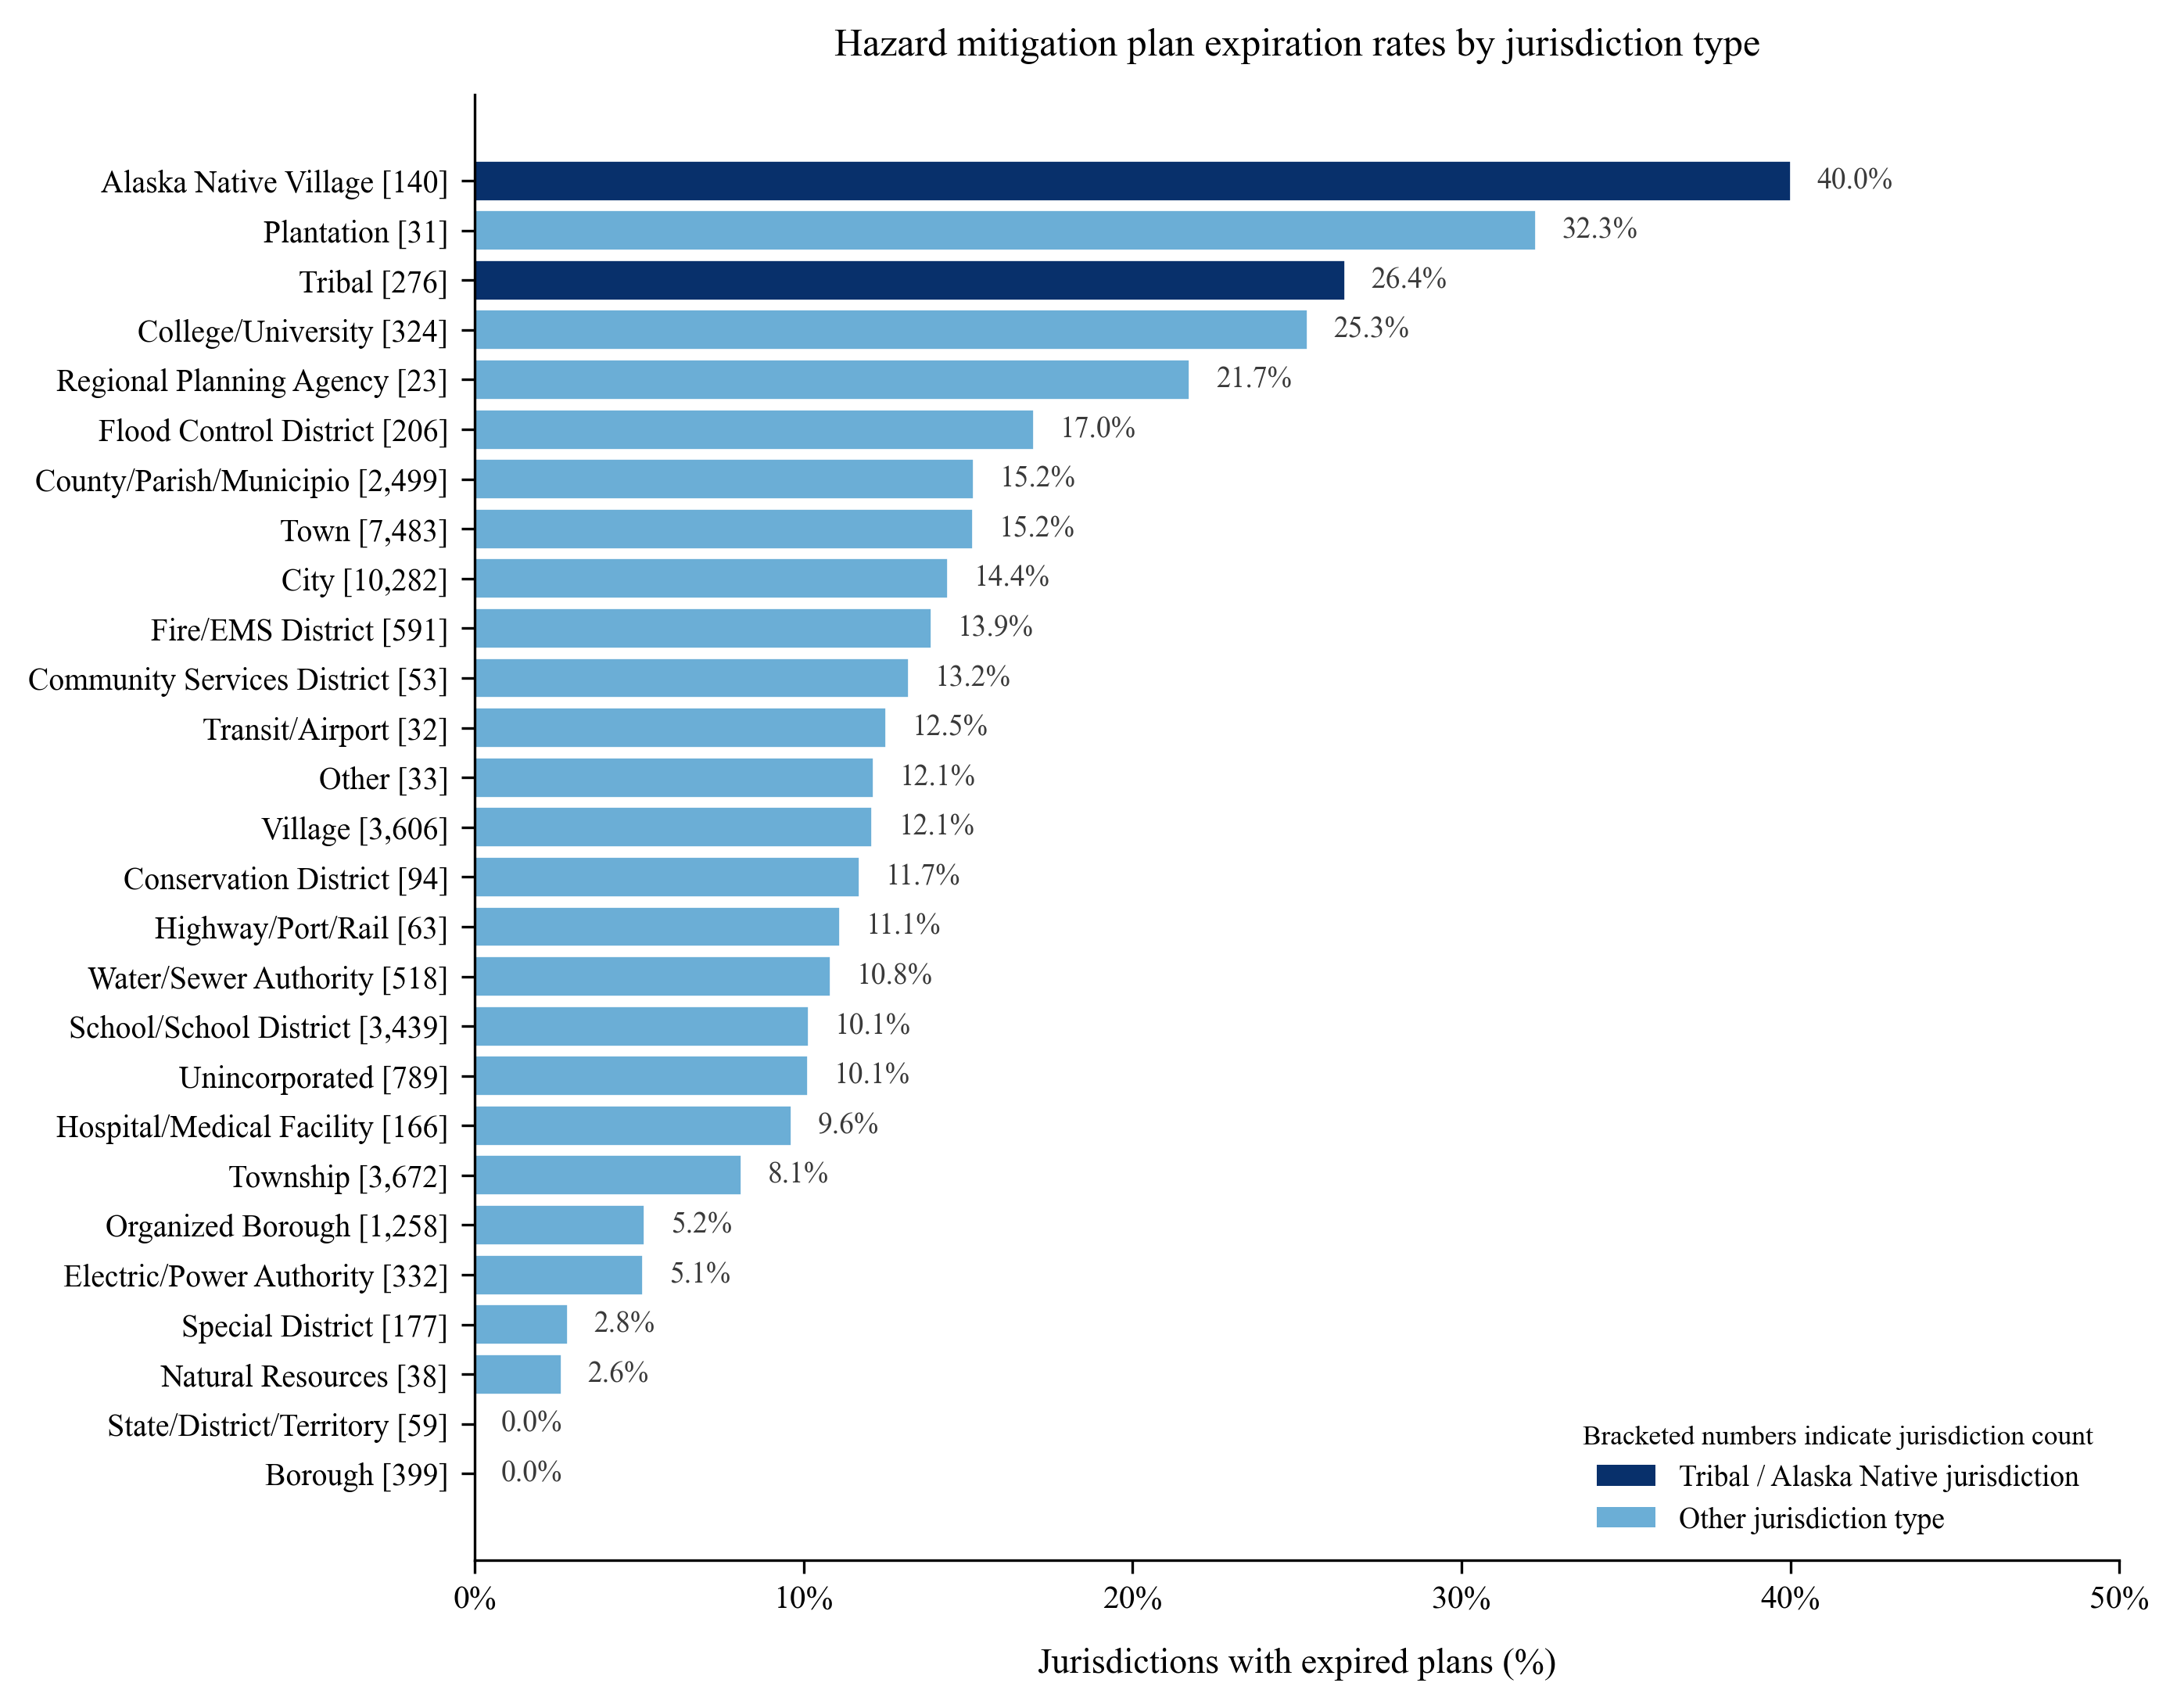

Saved: Figure_3-1_HMP_Expiration_by_Jurisdiction.png


In [18]:
# FIGURE 3-2: Plan expiration rates by jurisdiction type

exp_data = []
for name, grp in hmp.groupby(jtype_col):
    if len(grp) < 20:
        continue
    exp_n = (grp['planStatus'].str.lower() == 'expired').sum()
    pct   = exp_n / len(grp) * 100
    exp_data.append({'type': name, 'n': len(grp), 'expired': exp_n, 'rate': pct})

exp_df = pd.DataFrame(exp_data).sort_values('rate', ascending=True)

exp_df['is_tribal'] = exp_df['type'].str.contains(
    'tribal|alaska native', case=False, na=False
)

colors = [
    '#08306b' if row['is_tribal'] else '#6baed6'
    for _, row in exp_df.iterrows()
]

exp_df['label'] = exp_df.apply(
    lambda r: f"{r['type']} [{r['n']:,}]", axis=1
)

fig, ax = plt.subplots(figsize=(9.5, 7.5))

bars = ax.barh(
    exp_df['label'], exp_df['rate'],
    color=colors, edgecolor='white', linewidth=0.4
)

x_max = exp_df['rate'].max()
label_offset = x_max * 0.02

for bar, val in zip(bars, exp_df['rate']):
    ax.text(
        bar.get_width() + label_offset,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.1f}%',
        va='center', ha='left', fontsize=9, color=CHARCOAL
    )

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#08306b', label='Tribal / Alaska Native jurisdiction'),
    Patch(facecolor='#6baed6', label='Other jurisdiction type')
]
ax.legend(
    handles=legend_elements,
    title='Bracketed numbers indicate jurisdiction count',
    loc='lower right',
    fontsize=9,
    title_fontsize=8.5,
    frameon=False
)

ax.set_xlabel('Jurisdictions with expired plans (%)', labelpad=10)
ax.set_title('Hazard mitigation plan expiration rates by jurisdiction type', pad=12)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlim(0, x_max * 1.25)
ax.tick_params(axis='y', labelsize=9.5, pad=4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout(pad=1.5)
plt.savefig('Figure_3-1_HMP_Expiration_by_Jurisdiction.png', dpi=300,
            bbox_inches='tight', pad_inches=0.18)
plt.show()
print("Saved: Figure_3-1_HMP_Expiration_by_Jurisdiction.png")

### Figure 3-3. Program Application Share and Denial RatesTemplate failure type. Source: FEMA Hazard Mitigation Assistance Projects dataset. Panel A shows program composition for tribal versus non-tribal subrecipients; Panel B shows denial rates by program for each group.

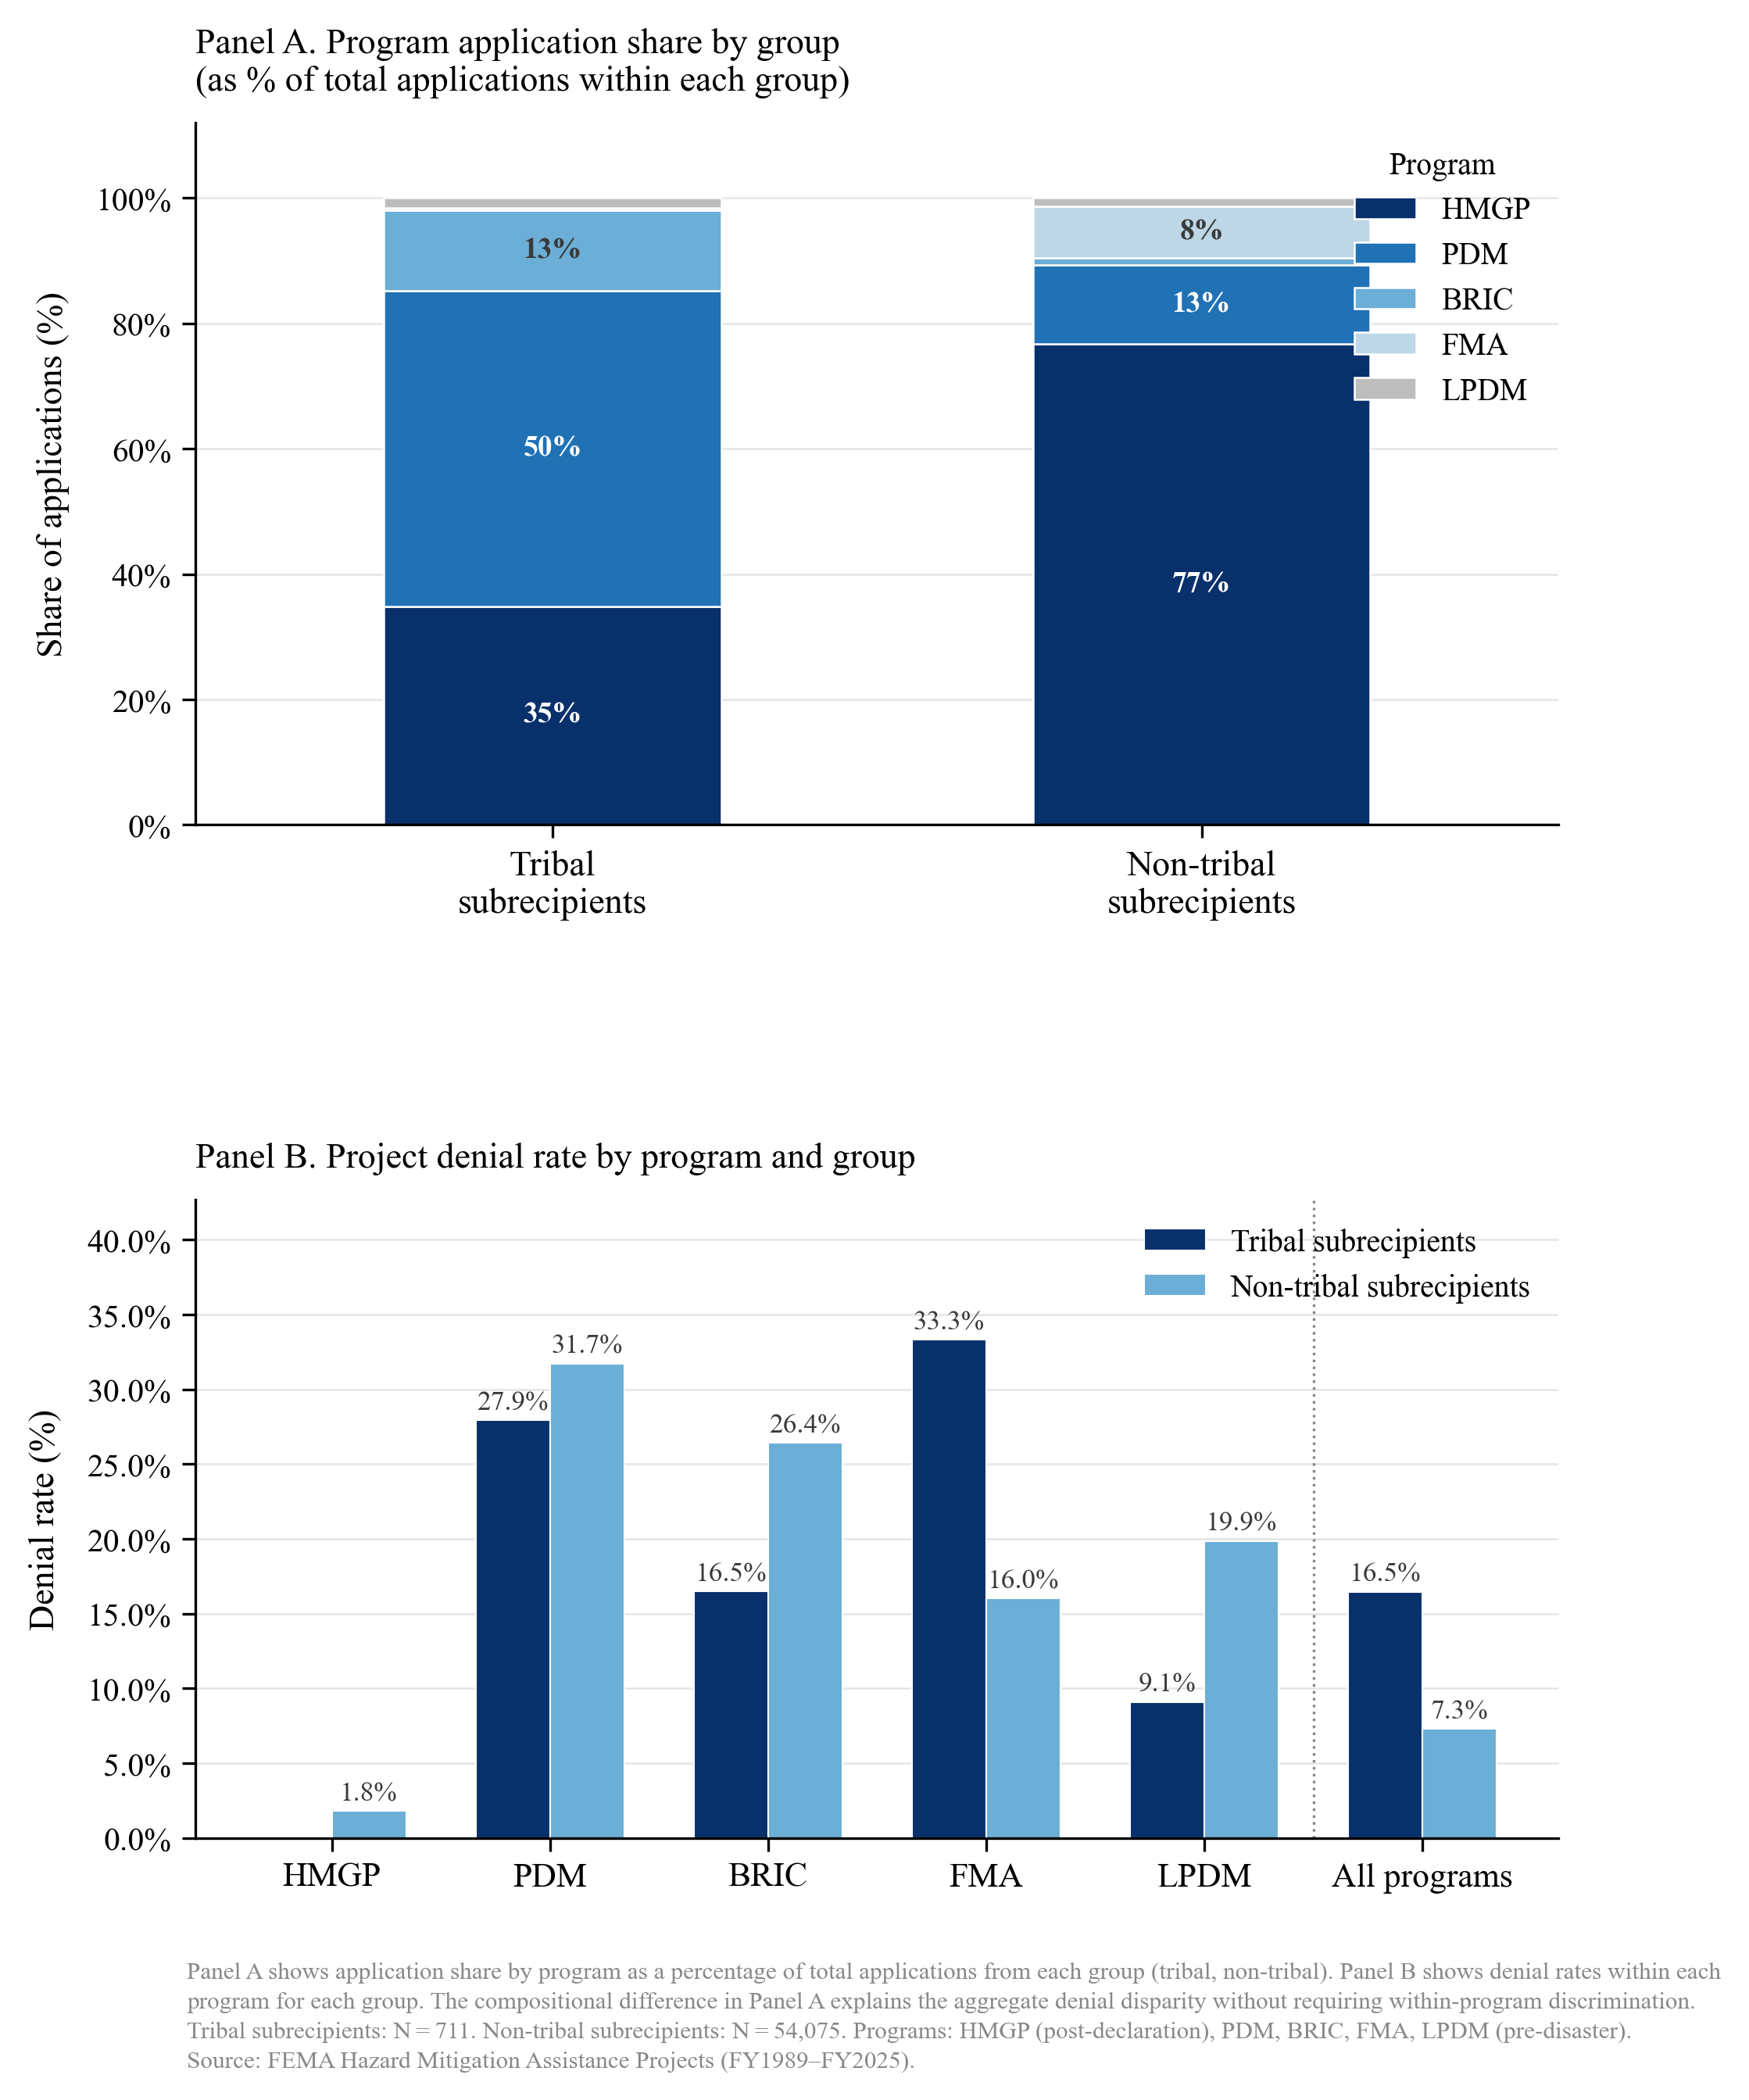

Saved: fig4_program_composition_denial.png


In [19]:

# FIGURE 3-3:
# Panel A: Stacked bars - program composition for tribal vs. non-tribal
# Panel B: Paired bars - denial rate by program for each group

if tribal_col in hma.columns:

    main_progs = ['HMGP', 'PDM', 'BRIC', 'FMA', 'LPDM']

    # Program colors - distinct, colorblind-accessible sequential palette
    PROG_COLORS_5 = ['#08306b', '#2171b5', '#6baed6', '#bdd7e7', '#bdbdbd']
    prog_color_map = dict(zip(main_progs, PROG_COLORS_5))

    # ── Panel A data ──────────────────────────────────────────────
    # tribal_shares and nontribal_shares already computed above in 3.3.4

    # ── Panel B data ──────────────────────────────────────────────
    # denial_tribal_by_prog and denial_nontribal_by_prog already computed above

    # ── Layout ────────────────────────────────────────────────────
    fig, (ax_top, ax_bot) = plt.subplots(
        2, 1,
        figsize=(7.5, 9.5),
        gridspec_kw={'height_ratios': [1.1, 1], 'hspace': 0.56}
    )

    # ── TOP PANEL: stacked bars ───────────────────────────────────
    x_pos    = [0, 1]
    x_labels = ['Tribal\nsubrecipients', 'Non-tribal\nsubrecipients']
    bar_width = 0.52

    bottom_t  = 0
    bottom_nt = 0

    for i, prog in enumerate(main_progs):
        val_t  = tribal_shares.get(prog, 0)
        val_nt = nontribal_shares.get(prog, 0)
        color  = PROG_COLORS_5[i]

        ax_top.bar(0, val_t,  bar_width, bottom=bottom_t,  color=color,
                   edgecolor='white', linewidth=0.6, label=prog)
        ax_top.bar(1, val_nt, bar_width, bottom=bottom_nt, color=color,
                   edgecolor='white', linewidth=0.6)

        # Label inside bar segments large enough to read
        font_color = 'white' if i <= 1 else CHARCOAL
        if val_t >= 5:
            ax_top.text(0, bottom_t + val_t / 2, f'{val_t:.0f}%',
                        ha='center', va='center', fontsize=9, color=font_color,
                        fontweight='bold')
        if val_nt >= 5:
            ax_top.text(1, bottom_nt + val_nt / 2, f'{val_nt:.0f}%',
                        ha='center', va='center', fontsize=9, color=font_color,
                        fontweight='bold')

        bottom_t  += val_t
        bottom_nt += val_nt

    ax_top.set_xticks(x_pos)
    ax_top.set_xticklabels(x_labels, fontsize=11)
    ax_top.set_xlim(-0.55, 1.55)
    ax_top.set_ylabel('Share of applications (%)', labelpad=8)
    ax_top.set_title(
        'Panel A. Program application share by group\n'
        '(as % of total applications within each group)',
        loc='left', fontsize=11, pad=10
    )
    ax_top.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax_top.set_ylim(0, 112)
    ax_top.legend(
        title='Program', loc='upper right', fontsize=9.5,
        title_fontsize=9.5, frameon=False, ncol=1
    )
    ax_top.spines['top'].set_visible(False)
    ax_top.spines['right'].set_visible(False)
    ax_top.set_axisbelow(True)
    ax_top.yaxis.grid(True, color='#e5e5e5', linewidth=0.6)

    # ── BOTTOM PANEL: paired denial rates by program ──────────────
    progs_with_total = main_progs + ['All programs']
    x     = np.arange(len(progs_with_total))
    width = 0.34

    t_vals  = [denial_tribal_by_prog.get(p, 0)    for p in main_progs]
    nt_vals = [denial_nontribal_by_prog.get(p, 0) for p in main_progs]

    # Aggregate denial rate across all five programs
    t_all  = hma[hma['tribal'] == 1]['denied'].mean() * 100
    nt_all = hma[hma['tribal'] == 0]['denied'].mean() * 100
    t_vals  = t_vals  + [t_all]
    nt_vals = nt_vals + [nt_all]

    bars_t  = ax_bot.bar(x - width / 2, t_vals,  width,
                         label='Tribal subrecipients',
                         color='#08306b', edgecolor='white', linewidth=0.5)
    bars_nt = ax_bot.bar(x + width / 2, nt_vals, width,
                         label='Non-tribal subrecipients',
                         color='#6baed6', edgecolor='white', linewidth=0.5)

    for bar, val in zip(list(bars_t) + list(bars_nt), t_vals + nt_vals):
        if val > 0:
            ax_bot.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.35,
                f'{val:.1f}%',
                ha='center', va='bottom', fontsize=8.5, color=CHARCOAL
            )

    ax_bot.set_xticks(x)
    ax_bot.set_xticklabels(progs_with_total, fontsize=10.5)
    ax_bot.axvline(len(main_progs) - 0.5, color=MID_GREY, linestyle=':', linewidth=0.8)
    ax_bot.set_ylabel('Denial rate (%)', labelpad=8)
    ax_bot.set_title(
        'Panel B. Project denial rate by program and group',
        loc='left', fontsize=11, pad=10
    )
    ax_bot.yaxis.set_major_formatter(mtick.PercentFormatter())
    max_denial = max(t_vals + nt_vals)
    ax_bot.set_ylim(0, max_denial * 1.28)
    ax_bot.legend(loc='upper right', fontsize=9.5, frameon=False)
    ax_bot.spines['top'].set_visible(False)
    ax_bot.spines['right'].set_visible(False)
    ax_bot.set_axisbelow(True)
    ax_bot.yaxis.grid(True, color='#e5e5e5', linewidth=0.6)

    # ── Shared footnote ───────────────────────────────────────────
    n_tribal_f    = (hma['tribal'] == 1).sum()
    n_nontribal_f = (hma['tribal'] == 0).sum()

    fig.text(
        0.12, 0.005,
        'Panel A shows application share by program as a percentage of total applications '
        'from each group (tribal, non-tribal). Panel B shows denial rates within each\n'
        'program for each group. The compositional difference in Panel A explains the '
        'aggregate denial disparity without requiring within-program discrimination.\n'
        f'Tribal subrecipients: N\u2009=\u2009{n_tribal_f:,}. '
        f'Non-tribal subrecipients: N\u2009=\u2009{n_nontribal_f:,}. '
        f'Programs: HMGP (post-declaration), PDM, BRIC, FMA, LPDM (pre-disaster).\n'
        f'Source: FEMA Hazard Mitigation Assistance Projects (FY1989\u2013FY2025).',
        fontsize=7.5, color=MID_GREY, verticalalignment='bottom', linespacing=1.5
    )

    plt.savefig('Figure_3-2_Program_Composition_Denial.png', dpi=300,
                bbox_inches='tight', pad_inches=0.18)
    plt.show()
    print("Saved: fig4_program_composition_denial.png")

### Figure 3-4. Proactive Mitigation Investment Share by Social Vulnerability QuartileResource failure type. Source: FEMA Hazard Mitigation Assistance Projects matched to county-level SVI scores.

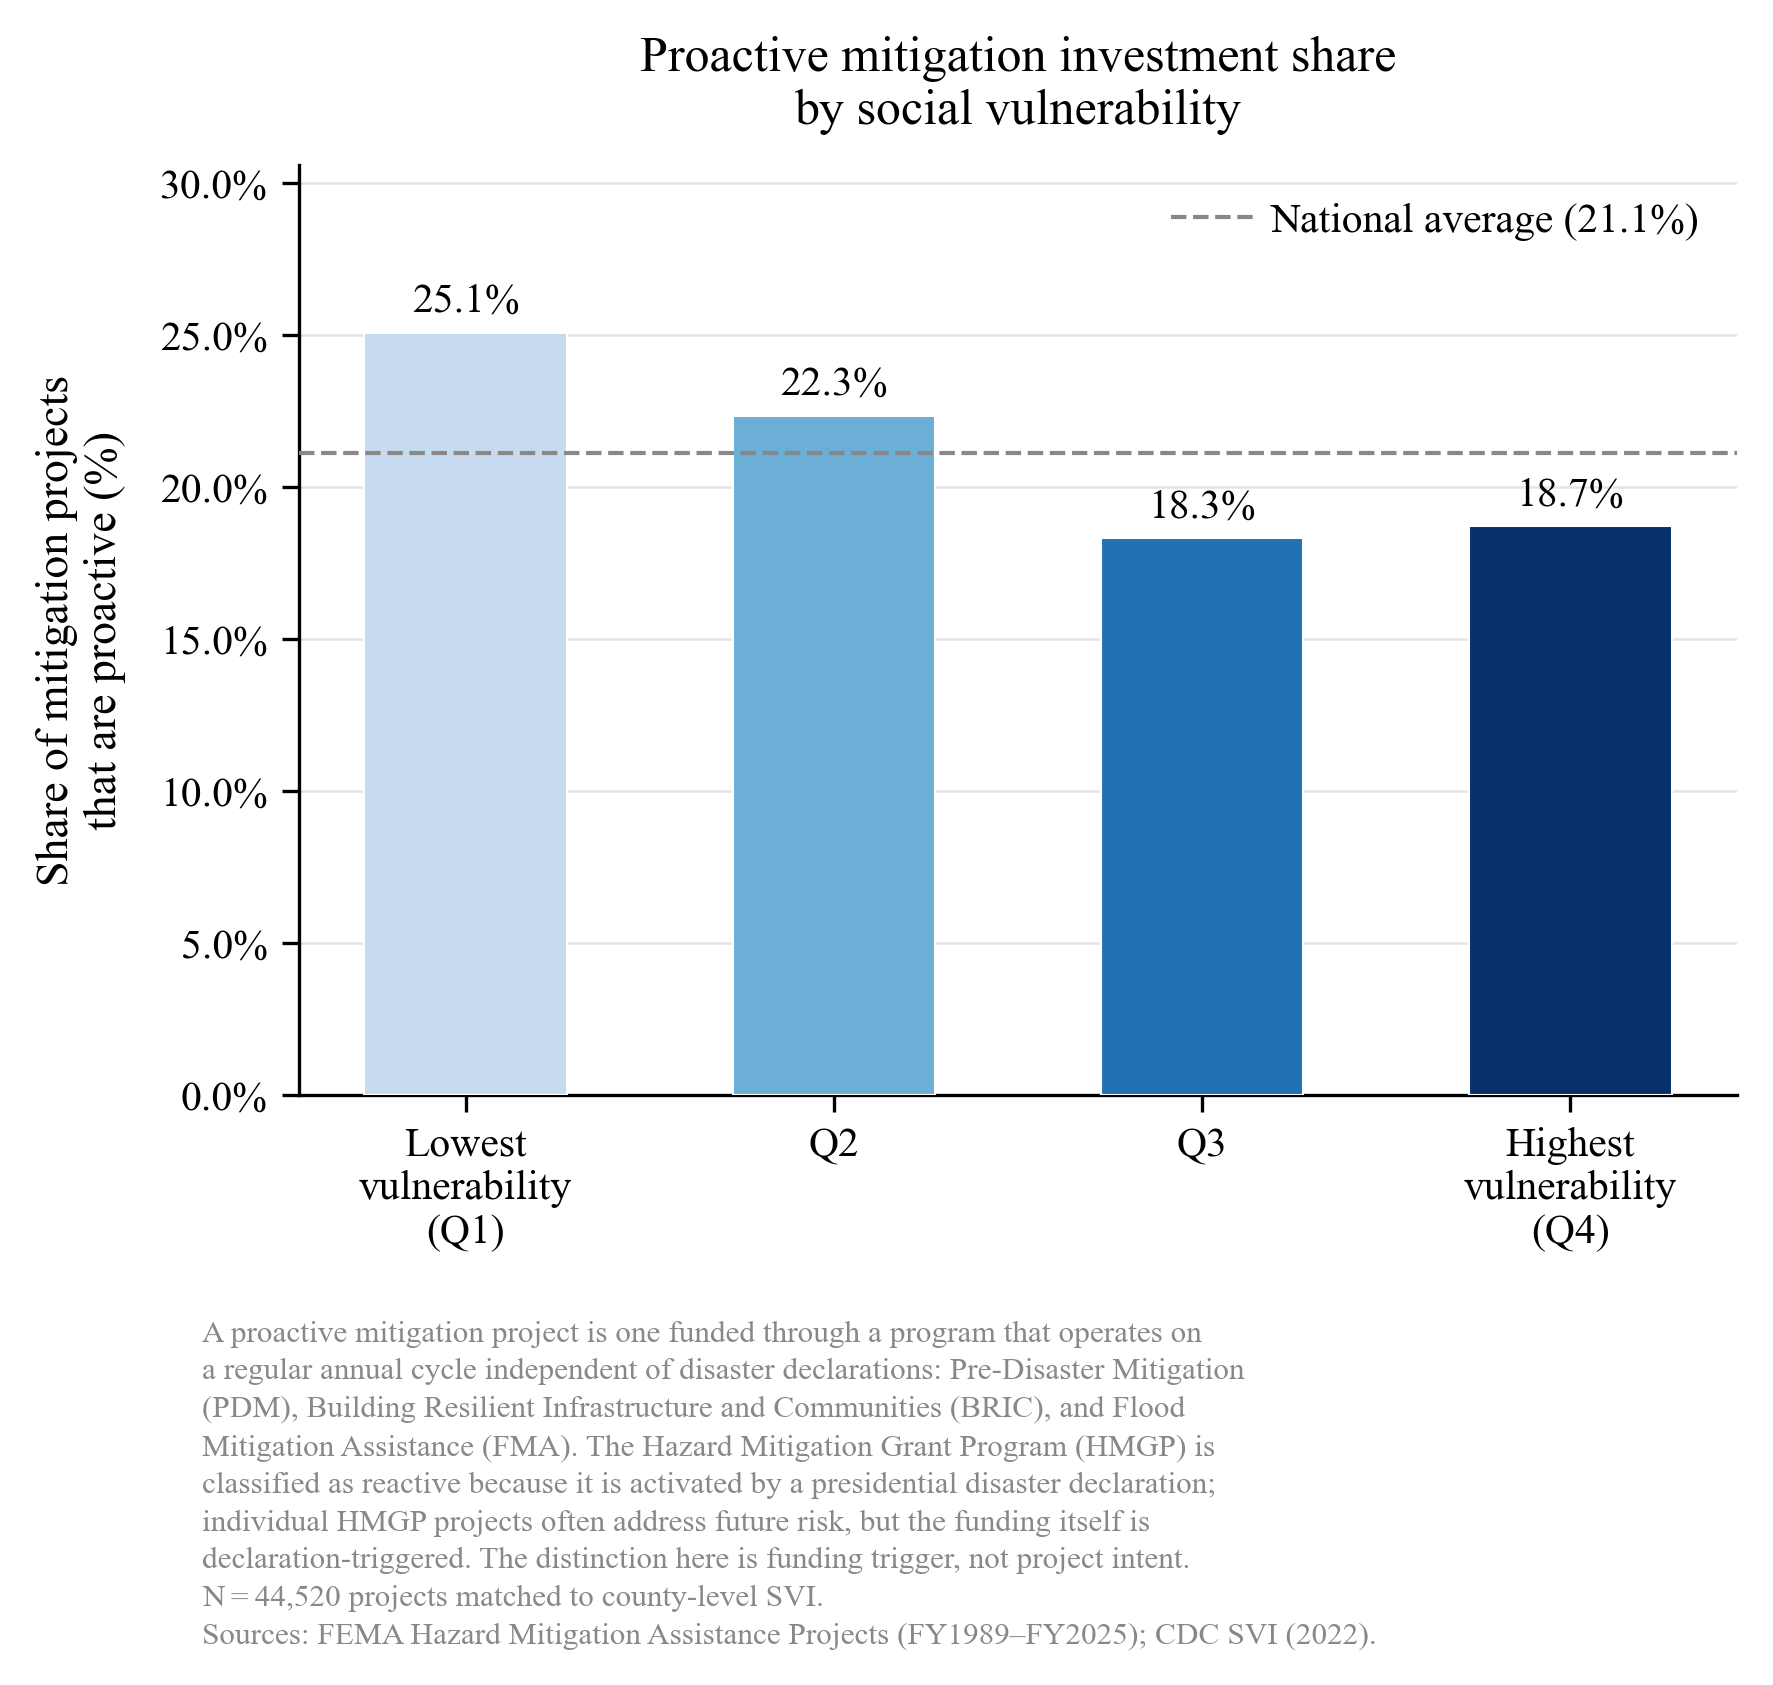

Saved: fig2_proactive_investment_by_vulnerability.png
  Proactive share by quartile:
    Lowest vulnerability (Q1)           25.1%
    Q2                                  22.3%
    Q3                                  18.3%
    Highest vulnerability (Q4)          18.7%
  National average: 21.1%
  N projects: 44,520


In [20]:

# FIGURE 3-4
# Proactive mitigation investment share by social vulnerability
# Resource failure: proactive investment flows away from need
#
# REVISED NOTE (per committee feedback):
#   - "pre-disaster" added to program descriptions
#   - HMGP classification clarified as funding-trigger distinction,
#     not project-type distinction

fig, ax = plt.subplots(figsize=(6.0, 5.6))

bars = ax.bar(
    proactive_by_q['quartile'],
    proactive_by_q['proactive_pct'],
    color=Q_COLORS,
    width=0.55,
    edgecolor='white',
    linewidth=0.5,
    zorder=3
)

for bar, val in zip(bars, proactive_by_q['proactive_pct']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.4,
        f'{val:.1f}%',
        ha='center', va='bottom', fontsize=10
    )

overall_proactive = hma_valid['is_proactive'].mean() * 100
ax.axhline(overall_proactive, color=MID_GREY, linestyle='--',
           linewidth=1.0, label=f'National average ({overall_proactive:.1f}%)', zorder=4)

ax.set_ylabel('Share of mitigation projects\nthat are proactive (%)', labelpad=8)
ax.set_title('Proactive mitigation investment share\nby social vulnerability', pad=10)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylim(0, proactive_by_q['proactive_pct'].max() * 1.22)
ax.legend(loc='upper right', handletextpad=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_axisbelow(True)
ax.yaxis.grid(True, color='#e5e5e5', linewidth=0.6, zorder=0)

plt.tight_layout()
plt.subplots_adjust(bottom=0.34)

# REVISED footnote: pre-disaster programs named explicitly; HMGP
# characterized by funding trigger (post-declaration), not project type
footnote2 = (
    'A proactive mitigation project is one funded through a program that operates on\n'
    'a regular annual cycle independent of disaster declarations: Pre-Disaster Mitigation\n'
    '(PDM), Building Resilient Infrastructure and Communities (BRIC), and Flood\n'
    'Mitigation Assistance (FMA). The Hazard Mitigation Grant Program (HMGP) is\n'
    'classified as reactive because it is activated by a presidential disaster declaration;\n'
    'individual HMGP projects often address future risk, but the funding itself is\n'
    'declaration-triggered. The distinction here is funding trigger, not project intent.\n'
    f'N\u2009=\u2009{len(hma_valid):,} projects matched to county-level SVI.\n'
    f'Sources: FEMA Hazard Mitigation Assistance Projects (FY1989\u2013FY2025); CDC SVI (2022).'
)
fig.text(0.12, 0.01, footnote2, fontsize=7.5, color=MID_GREY,
         verticalalignment='bottom', linespacing=1.5)
plt.savefig('Figure_3-3_Proactive_Investment_by_SVI.png')
plt.show()
print(f"Saved: fig2_proactive_investment_by_vulnerability.png")
print(f"  Proactive share by quartile:")
for _, row in proactive_by_q.iterrows():
    print(f"    {str(row['quartile']).replace(chr(10),' '):<35} {row['proactive_pct']:.1f}%")
print(f"  National average: {overall_proactive:.1f}%")
print(f"  N projects: {len(hma_valid):,}")

### Figure 3-5. Federal Risk Estimates Versus Observed Losses by CountyInformation failure type. Source: FEMA National Risk Index benchmarked against SHELDUS historical losses 2000 through 2024 across 3,118 counties.

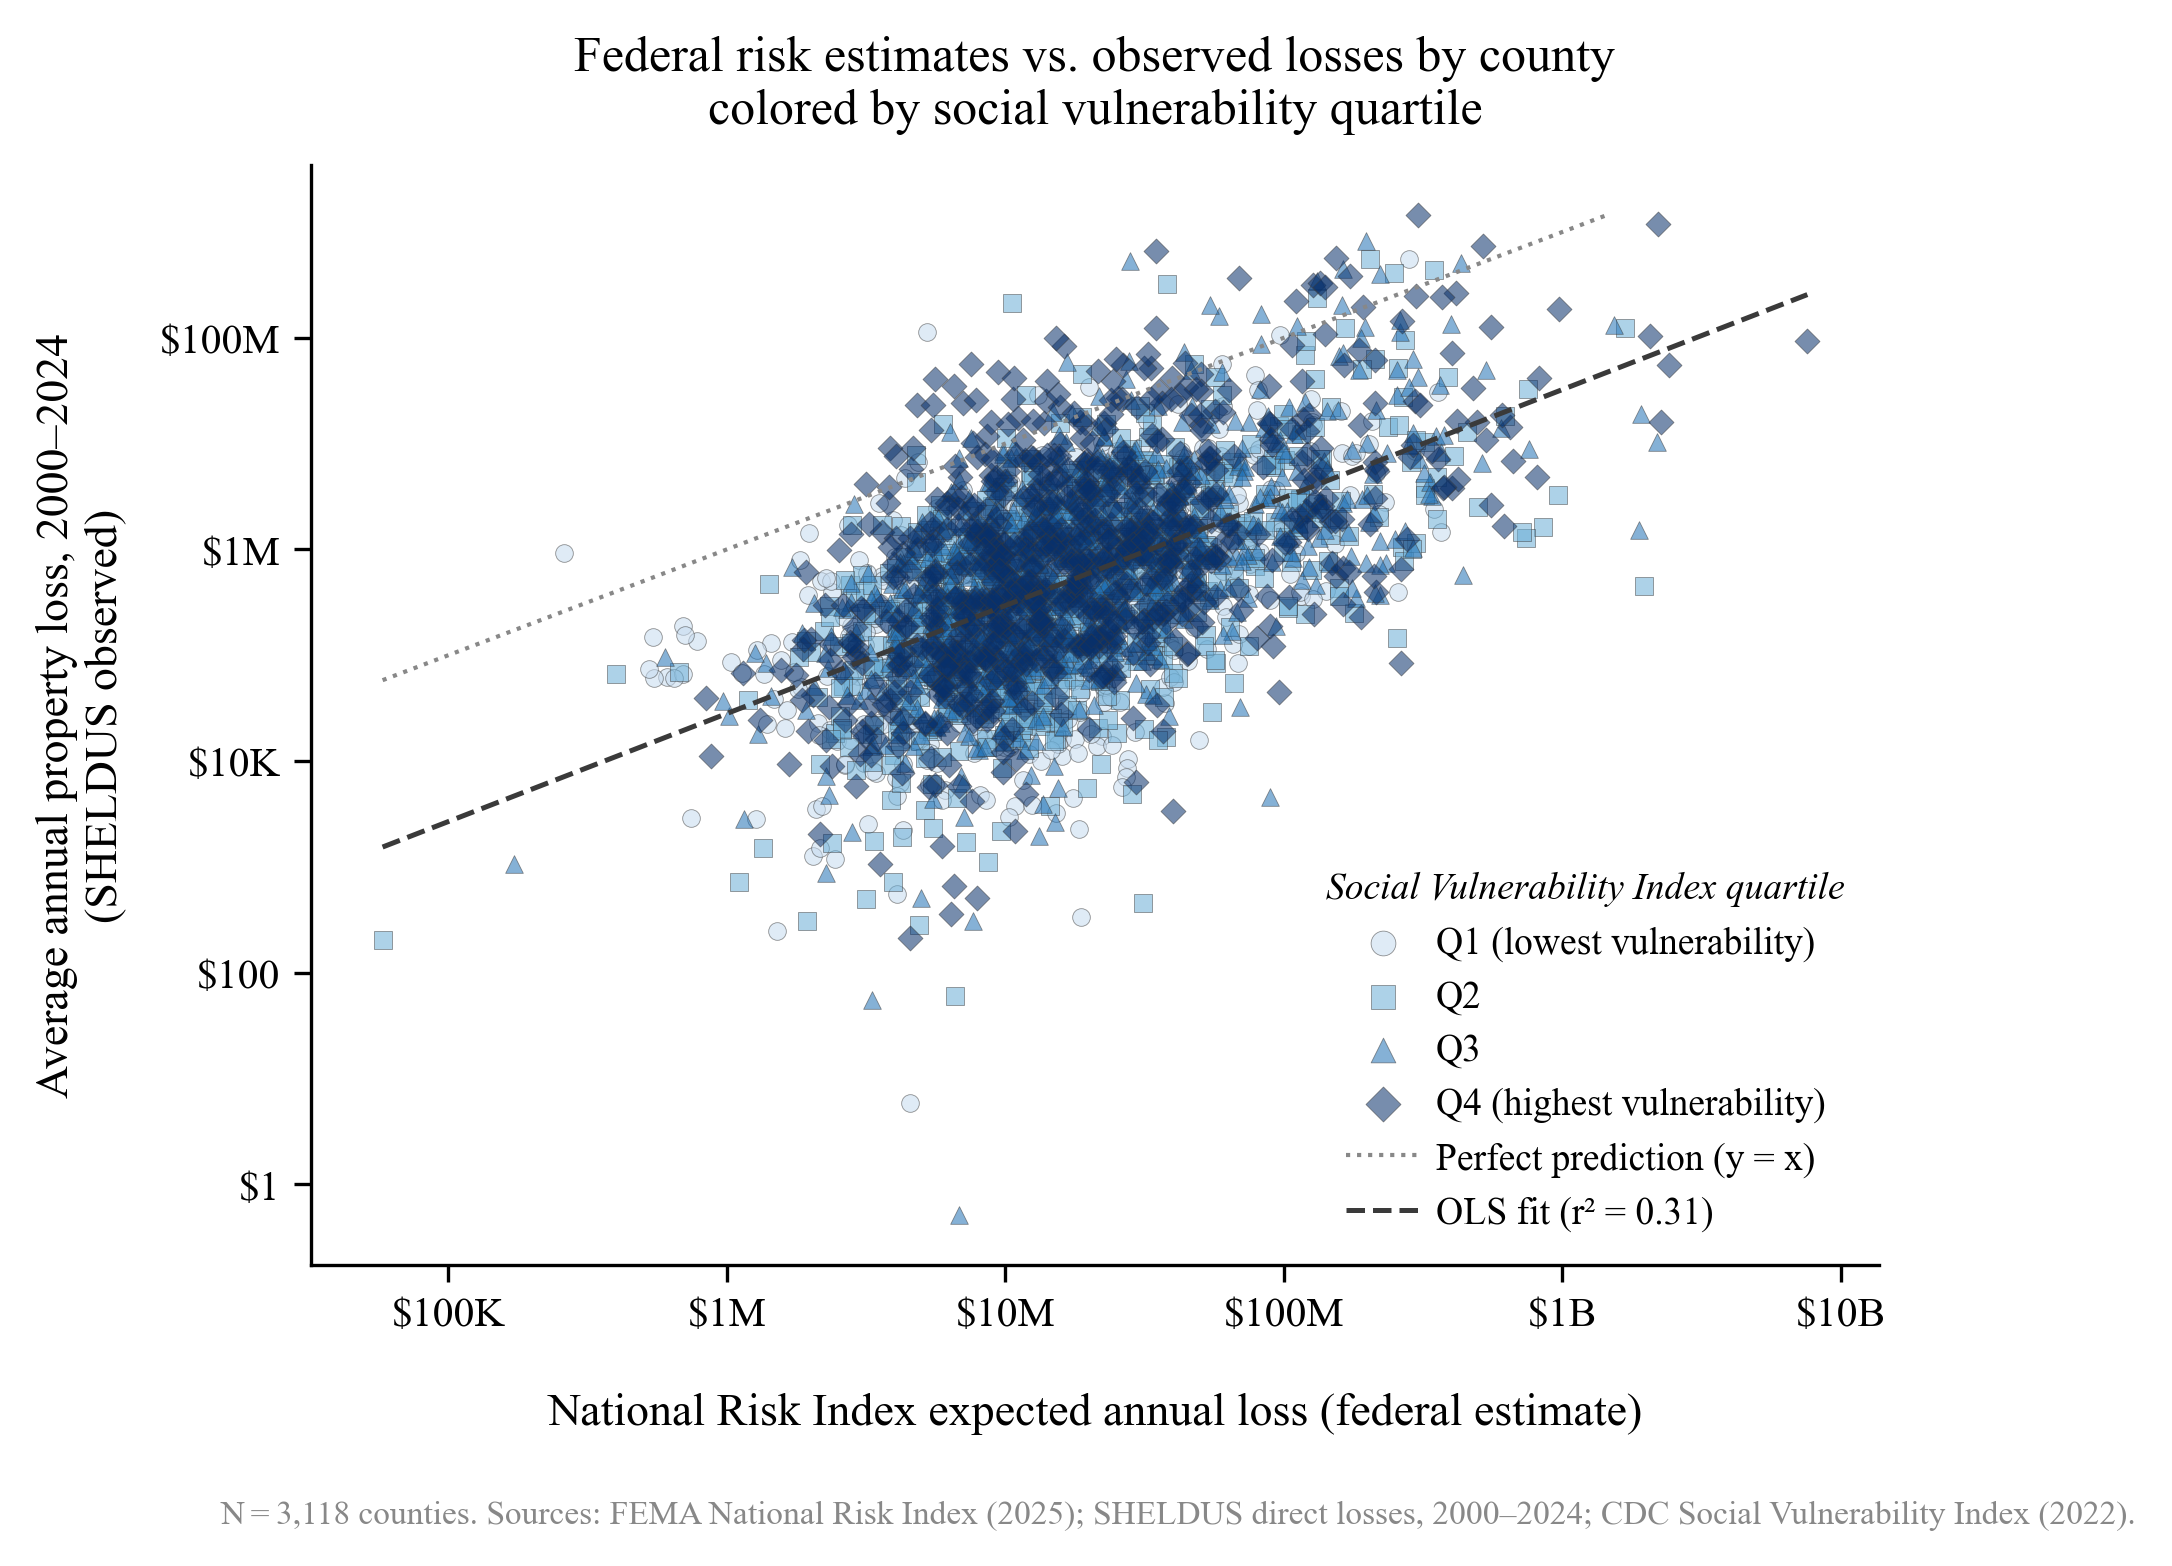

Saved: fig1_risk_measurement_vs_losses.png
  r² = 0.309 | slope = 1.021 | N = 3,118


In [21]:

# FIGURE 3-5
# Federal risk measurement vs. actual historical losses

compare = shel_county.merge(nri_sub, on='County_FIPS', how='inner')
compare = compare[(compare['sheldus_annual'] > 0) & (compare['NRI_EAL'] > 0)]
compare = compare.merge(svi_sub, left_on='County_FIPS', right_on='FIPS', how='left')
compare = compare[compare['RPL_THEMES'].notna() & (compare['RPL_THEMES'] >= 0)]

compare['svi_quartile'] = pd.qcut(
    compare['RPL_THEMES'], 4,
    labels=['Q1 (lowest vulnerability)', 'Q2', 'Q3', 'Q4 (highest vulnerability)']
)

log_x = np.log10(compare['NRI_EAL'])
log_y = np.log10(compare['sheldus_annual'])
slope, intercept, r, p, se = stats.linregress(log_x, log_y)
r2 = r ** 2

x_range = np.linspace(log_x.min(), log_x.max(), 200)
y_fit   = slope * x_range + intercept

fig, ax = plt.subplots(figsize=(6.5, 5.2))

q_labels  = ['Q1 (lowest vulnerability)', 'Q2', 'Q3', 'Q4 (highest vulnerability)']
q_markers = ['o', 's', '^', 'D']
for i, (qlabel, color, marker) in enumerate(zip(q_labels, Q_COLORS, q_markers)):
    sub = compare[compare['svi_quartile'] == qlabel]
    ax.scatter(
        np.log10(sub['NRI_EAL']),
        np.log10(sub['sheldus_annual']),
        s=18, alpha=0.55, color=color, linewidths=0.2,
        edgecolors=CHARCOAL, marker=marker,
        label=qlabel, zorder=2 + i
    )

lims = [max(log_x.min(), log_y.min()), min(log_x.max(), log_y.max())]
ax.plot(lims, lims, color=MID_GREY, linestyle=':', linewidth=1,
        label='Perfect prediction (y = x)', zorder=5)
ax.plot(x_range, y_fit, color=CHARCOAL, linestyle='--', linewidth=1.2,
        label=f'OLS fit (r\u00b2 = {r2:.2f})', zorder=6)

def log_dollar(x, _):
    v = 10 ** x
    if v >= 1e9:   return f'${v/1e9:.0f}B'
    elif v >= 1e6: return f'${v/1e6:.0f}M'
    elif v >= 1e3: return f'${v/1e3:.0f}K'
    return f'${v:.0f}'

ax.xaxis.set_major_formatter(mtick.FuncFormatter(log_dollar))
ax.yaxis.set_major_formatter(mtick.FuncFormatter(log_dollar))
ax.set_xlabel('National Risk Index expected annual loss (federal estimate)', labelpad=14)
ax.set_ylabel('Average annual property loss, 2000\u20132024\n(SHELDUS observed)', labelpad=8)
ax.set_title('Federal risk estimates vs. observed losses by county\ncolored by social vulnerability quartile', pad=10)

leg = ax.legend(loc='lower right', handletextpad=0.4, markerscale=1.4,
                title='Social Vulnerability Index quartile', title_fontsize=9,
                fontsize=9)
leg.get_title().set_style('italic')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
fig.text(0.12, 0.01,
         f'N\u2009=\u2009{len(compare):,} counties. Sources: FEMA National Risk Index (2025); '
         f'SHELDUS direct losses, 2000\u20132024; CDC Social Vulnerability Index (2022).',
         fontsize=8, color=MID_GREY, verticalalignment='bottom')
plt.savefig('Figure_3-4_Federal_Risk_vs_Observed_Losses.png')
plt.show()
print(f"Saved: fig1_risk_measurement_vs_losses.png")
print(f"  r\u00b2 = {r2:.3f} | slope = {slope:.3f} | N = {len(compare):,}")

### Figure 3-6. Governance Failure Types Evaluated Against Sendai Framework Target G IndicatorsConceptual diagram. Filled circles indicate the failure type falls short of the corresponding benchmark; open circles indicate no deficit identified. Structural mismatch failures violate all four benchmarks simultaneously.

Saved: Figure_3-6_Sendai_Mapping_Matrix.png


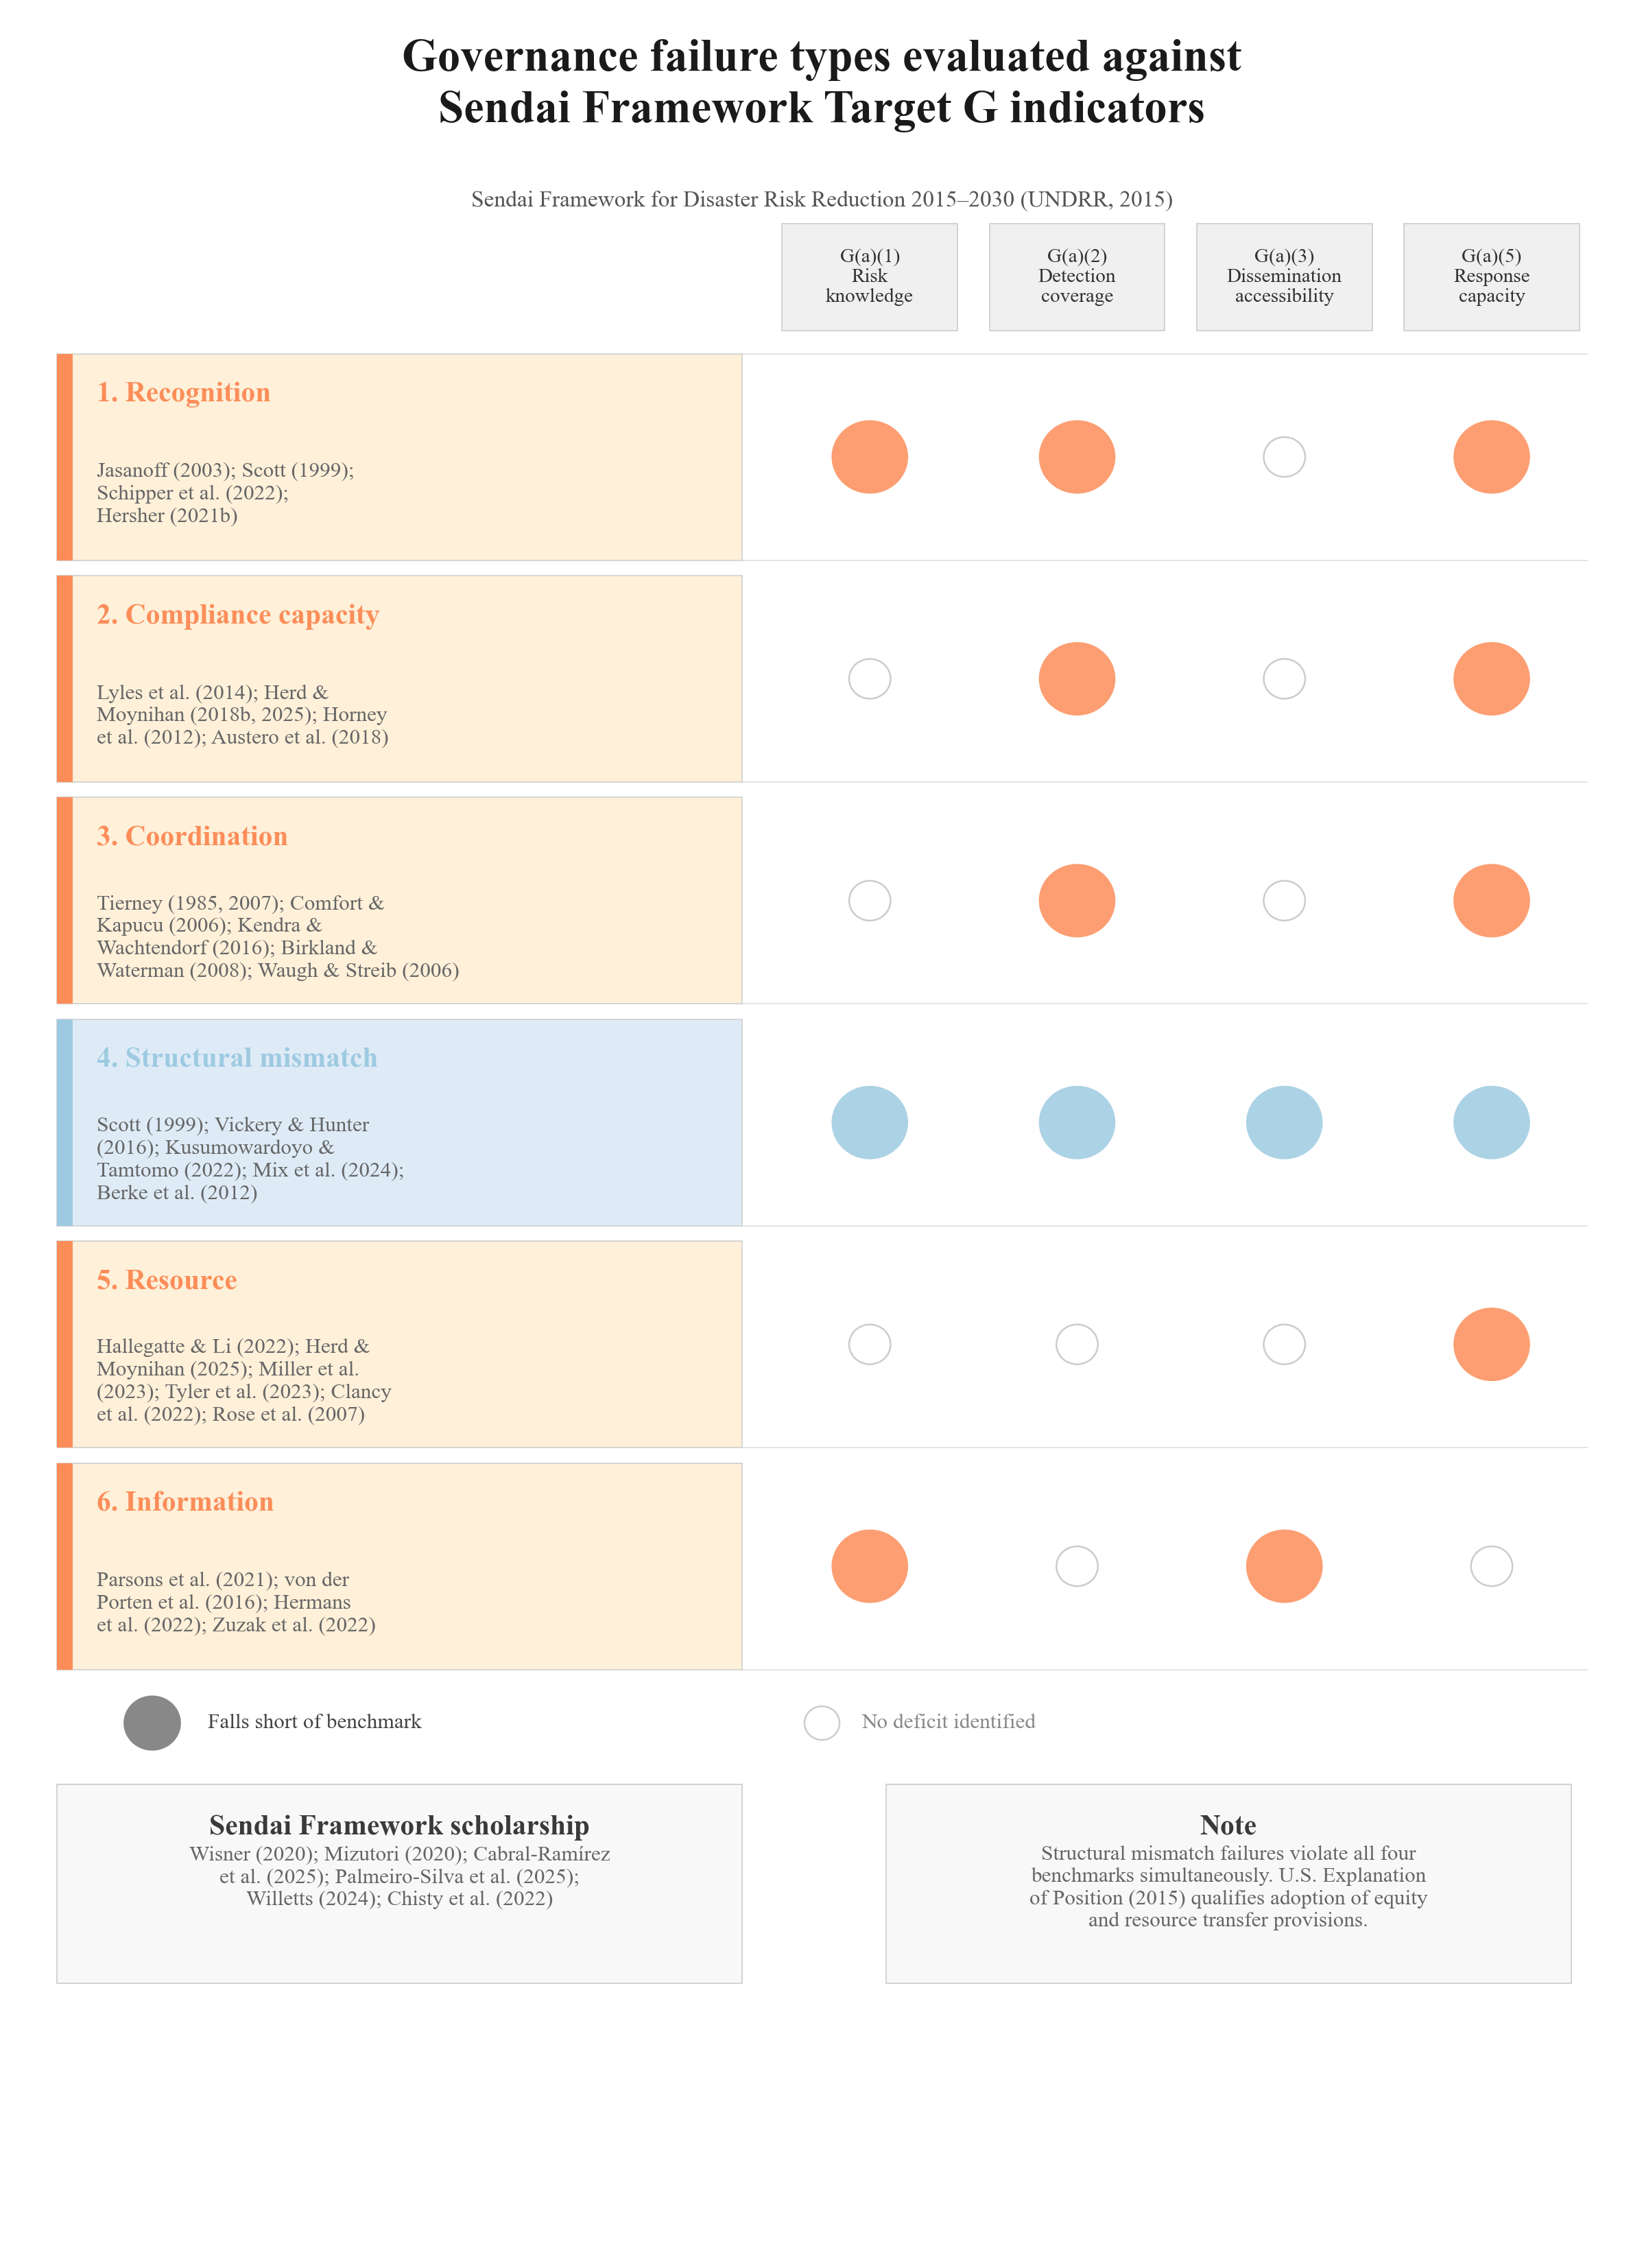


--- Both figures saved at 300 DPI ---


In [22]:

###############################################################################
# FIGURE 3-6: Sendai
###############################################################################

fig2, ax2 = plt.subplots(figsize=(10, 14))
ax2.set_xlim(0, 10)
ax2.set_ylim(-3.5, 11)
ax2.axis('off')

# Title block
ax2.text(5.0, 10.6,
    'Governance failure types evaluated against\nSendai Framework Target G indicators',
    ha='center', va='center', fontsize=HEAD_FS, fontweight='bold',
    color='#1a1a1a', linespacing=1.3)
ax2.text(5.0, 9.85,
    'Sendai Framework for Disaster Risk Reduction 2015\u20132030 (UNDRR, 2015)',
    ha='center', va='center', fontsize=BODY_FS, color='#555555')

# Column headers
col_cx = [5.3, 6.6, 7.9, 9.2]
col_labels = ['G(a)(1)\nRisk\nknowledge',
              'G(a)(2)\nDetection\ncoverage',
              'G(a)(3)\nDissemination\naccessibility',
              'G(a)(5)\nResponse\ncapacity']

for cx, lab in zip(col_cx, col_labels):
    rect = Rectangle((cx - 0.55, 9.0), 1.1, 0.7,
           facecolor='#f0f0f0', edgecolor='#cccccc', linewidth=LW_BORDER, zorder=2)
    ax2.add_patch(rect)
    ax2.text(cx, 9.35, lab, ha='center', va='center',
             fontsize=7, color='#333333', linespacing=1.15, zorder=3)

# Rows
rows = [
    (1, 'Recognition', P[1], [1, 1, 0, 1],
     'Jasanoff (2003); Scott (1999);\nSchipper et al. (2022);\nHersher (2021b)'),
    (2, 'Compliance capacity', P[2], [0, 1, 0, 1],
     'Lyles et al. (2014); Herd &\nMoynihan (2018b, 2025); Horney\net al. (2012); Austero et al. (2018)'),
    (3, 'Coordination', P[3], [0, 1, 0, 1],
     'Tierney (1985, 2007); Comfort &\nKapucu (2006); Kendra &\nWachtendorf (2016); Birkland &\nWaterman (2008); Waugh & Streib (2006)'),
    (4, 'Structural mismatch', P[4], [1, 1, 1, 1],
     'Scott (1999); Vickery & Hunter\n(2016); Kusumowardoyo &\nTamtomo (2022); Mix et al. (2024);\nBerke et al. (2012)'),
    (5, 'Resource', P[5], [0, 0, 0, 1],
     'Hallegatte & Li (2022); Herd &\nMoynihan (2025); Miller et al.\n(2023); Tyler et al. (2023); Clancy\net al. (2022); Rose et al. (2007)'),
    (6, 'Information', P[6], [1, 0, 1, 0],
     'Parsons et al. (2021); von der\nPorten et al. (2016); Hermans\net al. (2022); Zuzak et al. (2022)'),
]

row_h = 1.35
row_gap = 0.1
start_top = 8.85
lbl_x = 0.2
lbl_w = 4.3

for i, (num, name, pal, dots, cites) in enumerate(rows):
    top = start_top - i * (row_h + row_gap)
    cy = top - row_h / 2

    # Row box with left accent
    rect = Rectangle((lbl_x, top - row_h), lbl_w, row_h,
           facecolor=pal['fill'], edgecolor='#d0d0d0',
           linewidth=LW_BORDER, zorder=2)
    ax2.add_patch(rect)
    bar = Rectangle((lbl_x, top - row_h), 0.1, row_h,
          facecolor=pal['accent'], edgecolor='none', zorder=3)
    ax2.add_patch(bar)

    # Title
    ax2.text(lbl_x + 0.25, cy + row_h*0.3,
             f'{num}. {name}', ha='left', va='center',
             fontsize=TITLE_FS, fontweight='bold', color=pal['accent'], zorder=4)
    # Citations
    ax2.text(lbl_x + 0.25, cy - row_h*0.18,
             cites, ha='left', va='center',
             fontsize=CITE_FS, color='#666666', linespacing=1.25, zorder=4)

    # Grid line
    ax2.plot([lbl_x + lbl_w, 9.8], [top - row_h, top - row_h],
             color='#e0e0e0', linewidth=0.4, zorder=0)

    # Dots
    for j, val in enumerate(dots):
        dcx = col_cx[j]
        if val:
            ax2.add_patch(plt.Circle((dcx, cy), 0.24,
                          facecolor=pal['accent'], edgecolor='none',
                          alpha=0.85, zorder=3))
        else:
            ax2.add_patch(plt.Circle((dcx, cy), 0.13,
                          facecolor='none', edgecolor='#cccccc',
                          linewidth=0.6, zorder=3))

# Top grid
ax2.plot([lbl_x + lbl_w, 9.8], [start_top, start_top],
         color='#e0e0e0', linewidth=0.4, zorder=0)

# Legend
legy = -0.1
ax2.add_patch(plt.Circle((0.8, legy), 0.18,
              facecolor='#888888', edgecolor='none', zorder=3))
ax2.text(1.15, legy, 'Falls short of benchmark',
         ha='left', va='center', fontsize=CITE_FS, color='#444444')
ax2.add_patch(plt.Circle((5.0, legy), 0.11,
              facecolor='none', edgecolor='#cccccc', linewidth=0.6, zorder=3))
ax2.text(5.25, legy, 'No deficit identified',
         ha='left', va='center', fontsize=CITE_FS, color='#888888')

# Bottom panels
bottom_panel(ax2, 0.2, -1.8, 4.3, 1.3,
    'Sendai Framework scholarship',
    'Wisner (2020); Mizutori (2020); Cabral-Ramírez\n'
    'et al. (2025); Palmeiro-Silva et al. (2025);\n'
    'Willetts (2024); Chisty et al. (2022)')

bottom_panel(ax2, 5.4, -1.8, 4.3, 1.3,
    'Note',
    'Structural mismatch failures violate all four\n'
    'benchmarks simultaneously. U.S. Explanation\n'
    'of Position (2015) qualifies adoption of equity\n'
    'and resource transfer provisions.')

fig2.savefig('Figure_3-6_Sendai_Mapping_Matrix.png', dpi=300, bbox_inches='tight')
print("Saved: Figure_3-6_Sendai_Mapping_Matrix.png")
plt.show()

print("\n--- Both figures saved at 300 DPI ---")

In [23]:
from datetime import datetime
print("Finished:", datetime.now())

Finished: 2026-06-02 22:35:00.574886
